<a href="https://colab.research.google.com/github/aluizio142-ops/tech-challenge-4-obesidade/blob/main/C%C3%B3pia_de_TECH_CHALLENGE_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TECH CHALLENGE**

O problema: Imagina que você foi contratado como cientista de dados de um hospital e tem o desafio de desenvolver um modelo de Machine Learning para auxiliar os médicos e médicas a prever se uma pessoa pode ter obesidade.

A obesidade é uma condição médica caracterizada pelo acúmulo excessivo de gordura corporal, a ponto de prejudicar a saúde. Esse problema tem se tornado cada vez mais prevalente em todo o mundo, atingindo pessoas de todas as idades e classes sociais. As causas da obesidade são multifatoriais e envolvem uma combinação de fatores genéticos, ambientais e comportamentais.



✓ Construir uma visão analítica em um painel com principais insights obtidos com o estudo sobre obesidade para trazer insights para a equipe médica.

✓ Compartilhar o link da sua aplicação deployada no app do Streamlit + link do painel analítico + link do repositório do seu github com todo código desenvolvido em um arquivo .doc ou .txt para realizar o upload na plataforma online.

✓ Gravar um vídeo mostrando toda a estratégia utilizada e apresentação do sistema preditivo (algo em torno de 4min - 10min). Não se esqueça que tanto a visão do sistema preditivo quanto o dashboard analítico deve ser apresentado em uma visão de negócio.

**dicionario**:
Gender — (Gênero) Sexo biológico. Valores: Female , Male.
Age — (Idade) Idade em anos. Valores: numérico contínuo (mín 14, máx 61).

Height — (Altura) Altura em metros. Valores: numérico contínuo (ex.: 1.45–1.98 m).

Weight — (Peso) Peso em quilogramas. Valores: numérico contínuo (ex.: 39–173 kg).

family_history — (Family history of overweight) Histórico familiar de excesso de peso. Valores: yes (há histórico), no (não há).

FAVC — (Frequent consumption of high-caloric food) Consumo frequente de alimentos muito calóricos. Valores: yes (sim), no (não).

FCVC — (Frequency of consumption of vegetables) Frequência de consumo de vegetais nas refeições. Valores (escala 1–3): 1 raramente, 2 às vezes, 3
sempre. Nota: no arquivo os valores aparecem com decimais (ruído); interprete arredondando para o inteiro mais próximo.

NCP — (Number of main meals) Número de refeições principais por dia. Valores (escala 1–4): 1 uma refeição, 2 duas, 3 três, 4 quatro ou mais. Nota:
valores com decimais devem ser arredondados.

CAEC — (Consumption of food between meals) Consumo de lanches/comes entre as refeições. Valores: no (não consome), Sometimes (às vezes),
Frequently (frequentemente), Always (sempre).

SMOKE — (Smoking) Hábito de fumar. Valores: yes (fuma), no (não fuma).

CH2O — (Daily water consumption) Consumo diário de água. Valores (escala 1–3): 1 < 1 L/dia, 2 1–2 L/dia, 3 > 2 L/dia. Nota: arredonde valores decimais
para interpretar a categoria.

SCC — (Calories consumption monitoring) Monitora a ingestão calórica diária. Valores: yes (sim), no (não).

FAF — (Physical activity frequency) Frequência semanal de atividade física. Valores (escala 0–3): 0 nenhuma, 1 ~1–2×/sem, 2 ~3–4×/sem, 3 5×/sem ou
mais. Nota: arredonde valores decimais.

TUE — (Time using electronic devices) Tempo diário usando dispositivos eletrônicos. Valores (escala 0–2): 0 ~0–2 h/dia, 1 ~3–5 h/dia, 2 > 5 h/dia. Nota:
arredonde valores decimais.

CALC — (Alcohol consumption) Consumo de bebida alcoólica. Valores: no (não bebe), Sometimes (às vezes), Frequently (frequentemente), Always
(sempre).

MTRANS — (Transportation used / Mode of transport) Meio de transporte habitual. Valores: Automobile (carro), Motorbike (moto), Bike (bicicleta),
Public_Transportation (transporte público), Walking (a pé).

Obesity — (Target label / Nível de obesidade) Classe de peso corporal. Valores: Insufficient_Weight (abaixo do peso), Normal_Weight (peso normal),
Overweight_Level_I (sobrepeso I), Overweight_Level_II (sobrepeso II), Obesity_Type_I (obesidade I), Obesity_Type_II (obesidade II),
Obesity_Type_III (obesidade III).

In [2]:
import pandas as pd

In [3]:
base_csv = 'https://raw.githubusercontent.com/aluizio142-ops/tech-challenge-4-obesidade/refs/heads/main/Obesity.csv'

In [4]:
df_obes = pd.read_csv(base_csv)

In [5]:
df_obes.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [6]:
!pip install openpyxl

In [7]:
dicionario_xlsx = 'https://github.com/aluizio142-ops/tech-challenge-4-obesidade/blob/main/dicionario.xlsx?raw=true'

In [8]:
dicionario = pd.read_excel(dicionario_xlsx)

In [9]:
dicionario

,Variável (Coluna CSV),Descrição (Label),Tipo de Dado,Valores / Escala,Notas de Tratamento
0,Gender,Sexo biológico,Categórico,"Female, Male",NaN
1,Age,Idade em anos,Numérico,14 a 61,Contínuo
2,Height,Altura em metros,Numérico,ex.: 1.45 - 1.98,Contínuo
3,Weight,Peso em quilogramas,Numérico,ex.: 39 - 173,Contínuo
4,family_history,Histórico familiar de excesso de peso,Binário,"yes, no",NaN
5,FAVC,Consumo frequente de alimentos calóricos,Binário,"yes, no",NaN
6,FCVC,Frequência de consumo de vegetais,Escala (1-3),"1: Raramente, 2: Às vezes, 3: Sempre",Arredondar decimais
7,NCP,Número de refeições principais,Escala (1-4),"1, 2, 3, 4 ou mais",Arredondar decimais
8,CAEC,Consumo de lanches entre refeições,Categórico,"no, Sometimes, Frequently, Always",NaN
9,SMOKE,Hábito de fumar,Binário,"yes, no",NaN


In [10]:
## importado os dados, transcreveremos os termos do csv com o dicionario

In [11]:
col_mapping = dicionario.set_index('Variável (Coluna CSV)')['Descrição (Label)'].to_dict()
df_obes = df_obes.rename(columns=col_mapping)

In [12]:
df_obes.head()

,Sexo biológico,Idade em anos,Altura em metros,Peso em quilogramas,Histórico familiar de excesso de peso,Consumo frequente de alimentos calóricos,Frequência de consumo de vegetais,Número de refeições principais,Consumo de lanches entre refeições,Hábito de fumar,Consumo diário de água,Monitoramento de ingestão calórica,Frequência semanal de atividade física,Tempo diário de uso de eletrônicos,Consumo de bebida alcoólica,Meio de transporte habitual,Nível de obesidade (Target)
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [13]:
df_obes = df_obes.rename(columns={'Sexo biológico': 'sexo', 'Idade em anos': 'idade(anos)', 'Altura em metros': 'altura(m)',
'Peso em quilogramas': 'peso(kg)', 'Consumo diário de água': 'consumo agua (L/dia)',
'Frequência semanal de atividade física': 'frequencia semanal atividade fisica (x/semana)', 'Tempo diário de uso de eletrônicos':
'Tempo diário de uso de eletrônicos (h/dia)'})

In [14]:
df_obes.dtypes

,0
sexo,object
idade(anos),float64
altura(m),float64
peso(kg),float64
Histórico familiar de excesso de peso,object
Consumo frequente de alimentos calóricos,object
Frequência de consumo de vegetais,float64
Número de refeições principais,float64
Consumo de lanches entre refeições,object
Hábito de fumar,object


In [15]:
df_obes.shape

(2111, 17)

In [16]:
## verificar se há dados nulos

df_obes.isnull().sum()

,0
sexo,0
idade(anos),0
altura(m),0
peso(kg),0
Histórico familiar de excesso de peso,0
Consumo frequente de alimentos calóricos,0
Frequência de consumo de vegetais,0
Número de refeições principais,0
Consumo de lanches entre refeições,0
Hábito de fumar,0


In [17]:

df_obes = df_obes.replace('Automobile', 'carro')
df_obes = df_obes.replace('Motorbike', 'moto')
df_obes = df_obes.replace('Bike', 'bicicleta')
df_obes = df_obes.replace('Public_Transportation', 'transporte_publico')
df_obes = df_obes.replace('Walking', 'a_pe')
df_obes = df_obes.replace('Insufficient_Weight', 'abaixo_peso')
df_obes = df_obes.replace('Normal_Weight', 'peso_normal')
df_obes = df_obes.replace('Overweight_Level_I', 'sobre_peso_I')
df_obes = df_obes.replace('Overweight_Level_II', 'sobre_peso_II')
df_obes = df_obes.replace('Obesity_Type_I', 'obesidade_I')
df_obes = df_obes.replace('Obesity_Type_II', 'obesidade_II')
df_obes = df_obes.replace('Obesity_Type_III', 'obesidade_III')
df_obes = df_obes.replace('Female', 'feminino')
df_obes = df_obes.replace('Male', 'masculino')
df_obes = df_obes.replace('yes', 'sim')
df_obes = df_obes.replace('no', 'nao')
df_obes = df_obes.replace('Sometimes', 'as_vezes')
df_obes = df_obes.replace('Frequently', 'frequentemente')
df_obes = df_obes.replace('Always', 'sempre')

# arredondar apenas esses para 2.
df_obes['altura(m)'] = df_obes['altura(m)'].round(2)
df_obes['peso(kg)'] = df_obes['peso(kg)'].round(2)

# sem numeros decimais
df_obes['Frequência de consumo de vegetais'] = df_obes['Frequência de consumo de vegetais'].round(0)
df_obes['Número de refeições principais'] = df_obes['Número de refeições principais'].round(0)
df_obes['consumo agua (L/dia)'] = df_obes['consumo agua (L/dia)'].round(0)
df_obes['frequencia semanal atividade fisica (x/semana)'] = df_obes['frequencia semanal atividade fisica (x/semana)'].round(0)
df_obes['Tempo diário de uso de eletrônicos (h/dia)'] = df_obes['Tempo diário de uso de eletrônicos (h/dia)'].round(0)
df_obes['idade(anos)'] = df_obes['idade(anos)'].round(0)

In [18]:
df_obes['IMC'] = df_obes['peso(kg)'] / (df_obes['altura(m)'] ** 2).round(2)

In [19]:
df_obes

,sexo,idade(anos),altura(m),peso(kg),Histórico familiar de excesso de peso,Consumo frequente de alimentos calóricos,Frequência de consumo de vegetais,Número de refeições principais,Consumo de lanches entre refeições,Hábito de fumar,consumo agua (L/dia),Monitoramento de ingestão calórica,frequencia semanal atividade fisica (x/semana),Tempo diário de uso de eletrônicos (h/dia),Consumo de bebida alcoólica,Meio de transporte habitual,Nível de obesidade (Target),IMC
0,feminino,21.0,1.62,64.00,sim,nao,2.0,3.0,as_vezes,nao,2.0,nao,0.0,1.0,nao,transporte_publico,peso_normal,24.427481
1,feminino,21.0,1.52,56.00,sim,nao,3.0,3.0,as_vezes,sim,3.0,sim,3.0,0.0,as_vezes,transporte_publico,peso_normal,24.242424
2,masculino,23.0,1.80,77.00,sim,nao,2.0,3.0,as_vezes,nao,2.0,nao,2.0,1.0,frequentemente,transporte_publico,peso_normal,23.765432
3,masculino,27.0,1.80,87.00,nao,nao,3.0,3.0,as_vezes,nao,2.0,nao,2.0,0.0,frequentemente,a_pe,sobre_peso_I,26.851852
4,masculino,22.0,1.78,89.80,nao,nao,2.0,1.0,as_vezes,nao,2.0,nao,0.0,0.0,as_vezes,transporte_publico,sobre_peso_II,28.328076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,feminino,21.0,1.71,131.41,sim,sim,3.0,3.0,as_vezes,nao,2.0,nao,2.0,1.0,as_vezes,transporte_publico,obesidade_III,45.003425
2107,feminino,22.0,1.75,133.74,sim,sim,3.0,3.0,as_vezes,nao,2.0,nao,1.0,1.0,as_vezes,transporte_publico,obesidade_III,43.705882
2108,feminino,23.0,1.75,133.69,sim,sim,3.0,3.0,as_vezes,nao,2.0,nao,1.0,1.0,as_vezes,transporte_publico,obesidade_III,43.689542
2109,feminino,24.0,1.74,133.35,sim,sim,3.0,3.0,as_vezes,nao,3.0,nao,1.0,1.0,as_vezes,transporte_publico,obesidade_III,44.009901


In [20]:
df_obes.dtypes

,0
sexo,object
idade(anos),float64
altura(m),float64
peso(kg),float64
Histórico familiar de excesso de peso,object
Consumo frequente de alimentos calóricos,object
Frequência de consumo de vegetais,float64
Número de refeições principais,float64
Consumo de lanches entre refeições,object
Hábito de fumar,object


In [21]:
df_obes.describe()

,idade(anos),altura(m),peso(kg),Frequência de consumo de vegetais,Número de refeições principais,consumo agua (L/dia),frequencia semanal atividade fisica (x/semana),Tempo diário de uso de eletrônicos (h/dia),IMC
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.315964,1.701620,86.586035,2.423496,2.687826,2.014685,1.006632,0.664614,29.707327
std,6.357078,0.093368,26.191163,0.583905,0.809680,0.688616,0.895462,0.674009,8.015962
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000,12.994030
25%,20.000000,1.630000,65.470000,2.000000,3.000000,2.000000,0.000000,0.000000,24.324324
50%,23.000000,1.700000,83.000000,2.000000,3.000000,2.000000,1.000000,1.000000,28.739130
75%,26.000000,1.770000,107.430000,3.000000,3.000000,2.000000,2.000000,1.000000,35.986113
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000,50.866221


In [22]:
for column in df_obes.columns:
    print(f"\nContagem de valores para a coluna: {column}")
    print(df_obes[column].value_counts())


Contagem de valores para a coluna: sexo
sexo
masculino    1068
feminino     1043
Name: count, dtype: int64

Contagem de valores para a coluna: idade(anos)
idade(anos)
21.0    236
23.0    218
26.0    213
18.0    212
19.0    169
22.0    163
20.0    150
24.0     95
25.0     82
17.0     69
31.0     62
30.0     53
27.0     43
33.0     37
38.0     34
29.0     33
34.0     29
32.0     26
39.0     25
37.0     24
41.0     20
28.0     20
16.0     20
35.0     19
40.0     19
36.0      6
44.0      6
42.0      6
55.0      5
45.0      3
43.0      3
46.0      2
51.0      2
61.0      1
52.0      1
15.0      1
56.0      1
14.0      1
48.0      1
47.0      1
Name: count, dtype: int64

Contagem de valores para a coluna: altura(m)
altura(m)
1.70    125
1.75    122
1.62     96
1.76     96
1.65     88
1.60     77
1.72     76
1.63     75
1.77     71
1.71     68
1.64     66
1.74     66
1.67     66
1.79     65
1.78     64
1.61     62
1.68     61
1.80     59
1.66     58
1.69     54
1.82     50
1.73     43
1.84  

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

### Visualização das Características Categóricas por Gênero

Vamos gerar gráficos de contagem para todas as variáveis categóricas e ordinais (exceto idade, altura e peso), dividindo os dados por 'sexo' para observar as diferenças entre masculino e feminino.

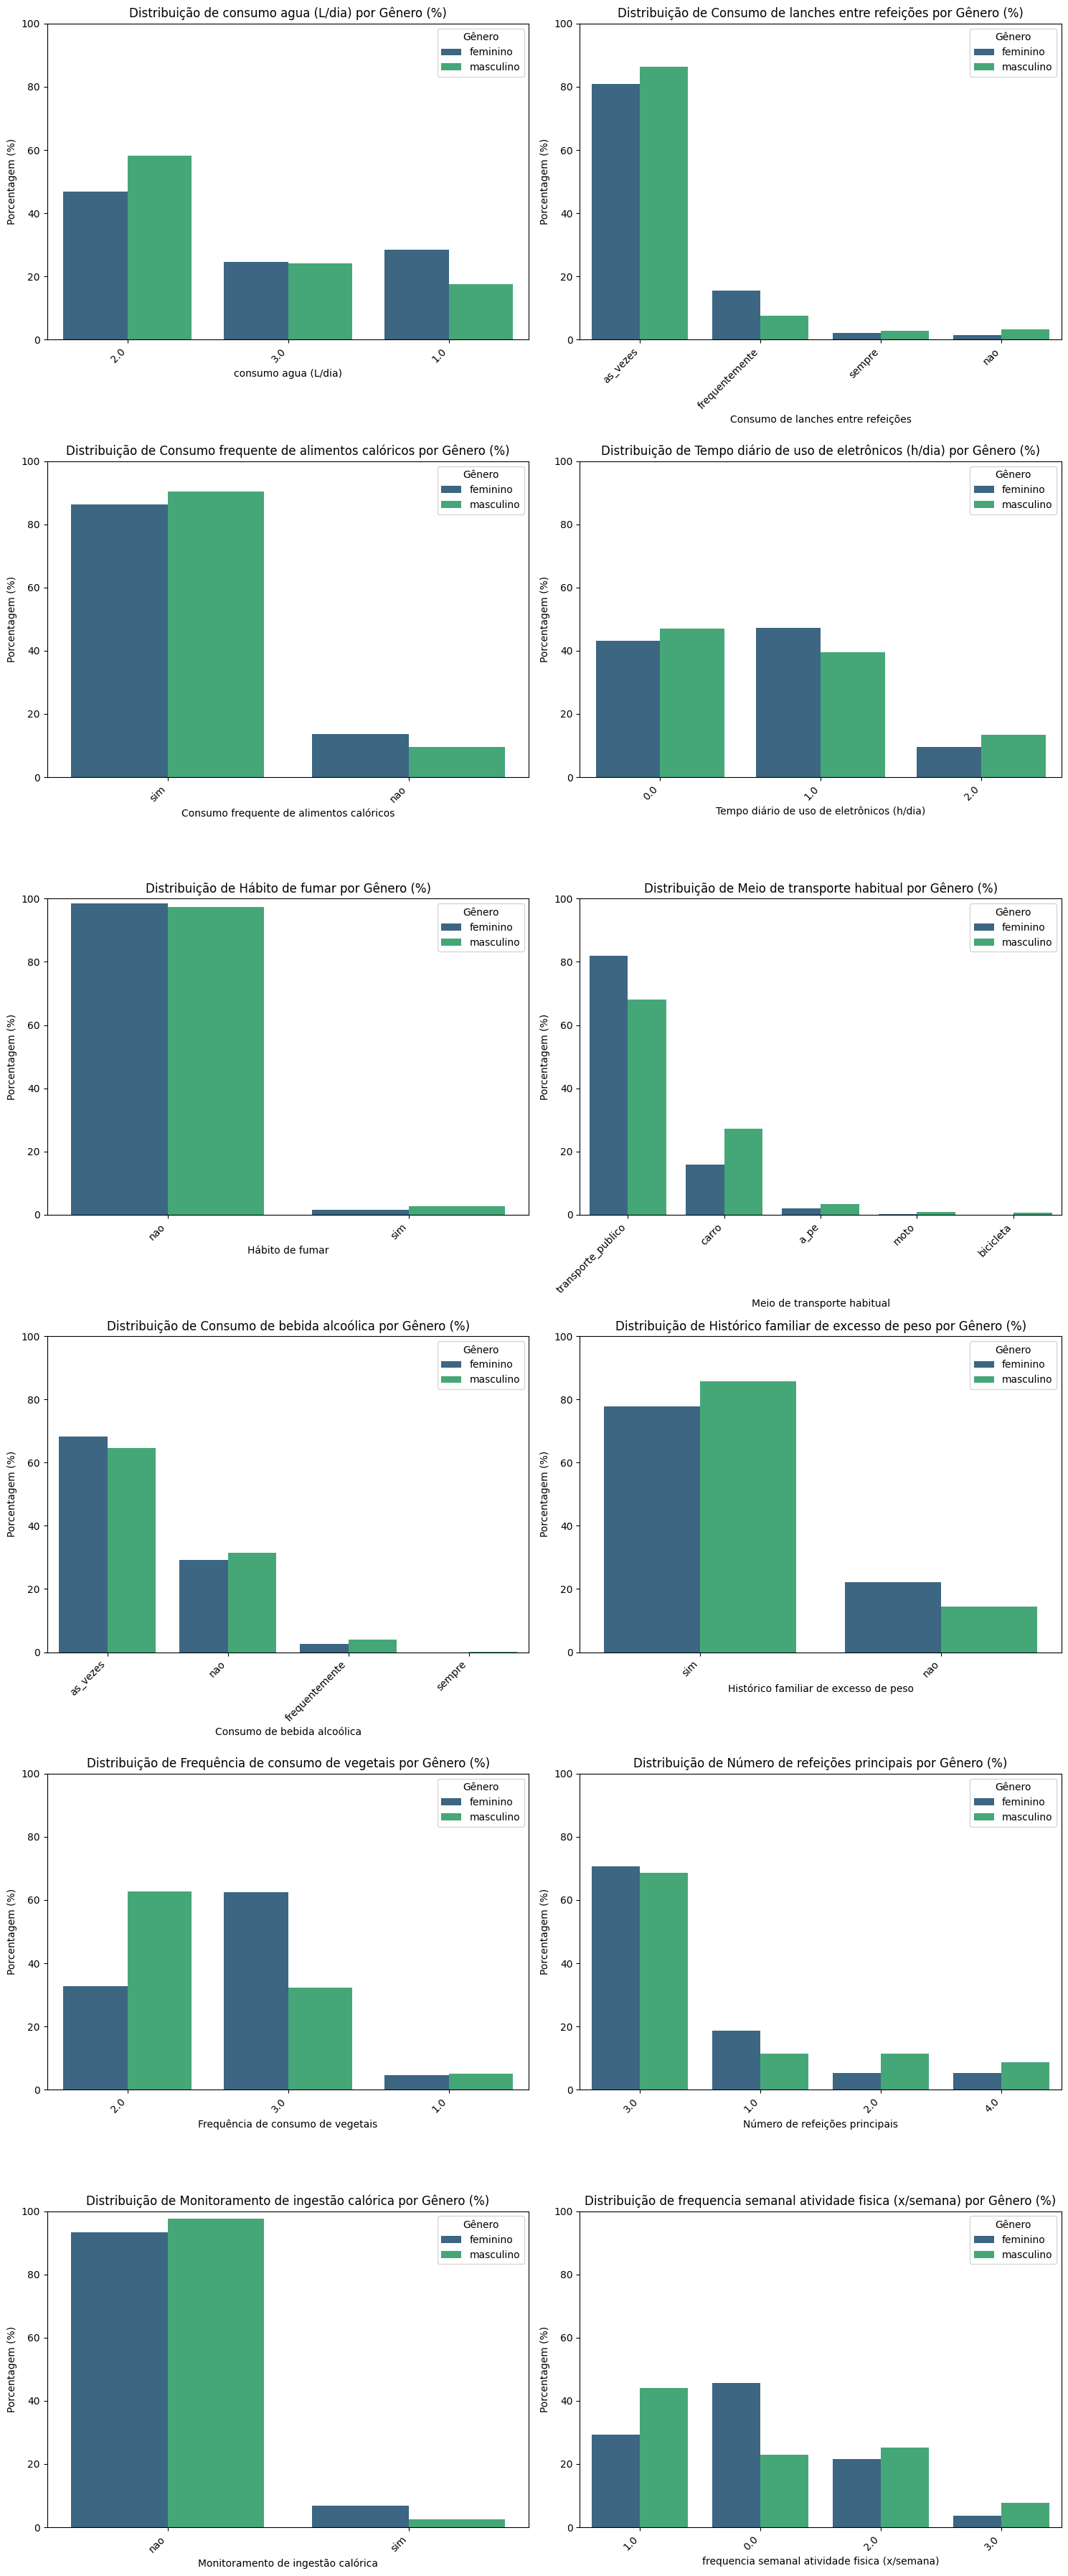

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Definir as colunas a serem excluídas da plotagem
excluded_columns = ['sexo', 'idade(anos)', 'altura(m)', 'peso(kg)', 'Nível de obesidade (Target)', 'IMC']

# Obter as colunas restantes para plotar (apenas categóricas ou ordinais para countplots)
columns_to_plot = [col for col in df_obes.columns if df_obes[col].dtype == 'object' and col not in excluded_columns]
ordinal_columns_for_percentages = [
    'Frequência de consumo de vegetais',
    'Número de refeições principais',
    'consumo agua (L/dia)',
    'frequencia semanal atividade fisica (x/semana)',
    'Tempo diário de uso de eletrônicos (h/dia)'
]
columns_to_plot.extend(ordinal_columns_for_percentages)
columns_to_plot = list(set(columns_to_plot)) # Remove duplicates

n_cols = 2
n_rows = (len(columns_to_plot) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 6 * n_rows))

for i, column in enumerate(columns_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)

    # Calculate percentages for each 'sexo' within each 'column' category
    grouped_counts = df_obes.groupby('sexo')[column].value_counts(normalize=True).mul(100).rename('percentage').reset_index()

    sns.barplot(data=grouped_counts, x=column, y='percentage', hue='sexo', palette='viridis', order=df_obes[column].value_counts().index)
    plt.title(f'Distribuição de {column} por Gênero (%)')
    plt.xlabel(column)
    plt.ylabel('Porcentagem (%)')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 100) # Ensure y-axis goes up to 100%
    plt.legend(title='Gênero', loc='upper right')

plt.tight_layout()
plt.show()

### Correlação entre Altura e Peso por Gênero

Agora, vamos visualizar a relação entre altura e peso, separando por gênero para identificar possíveis padrões diferentes.

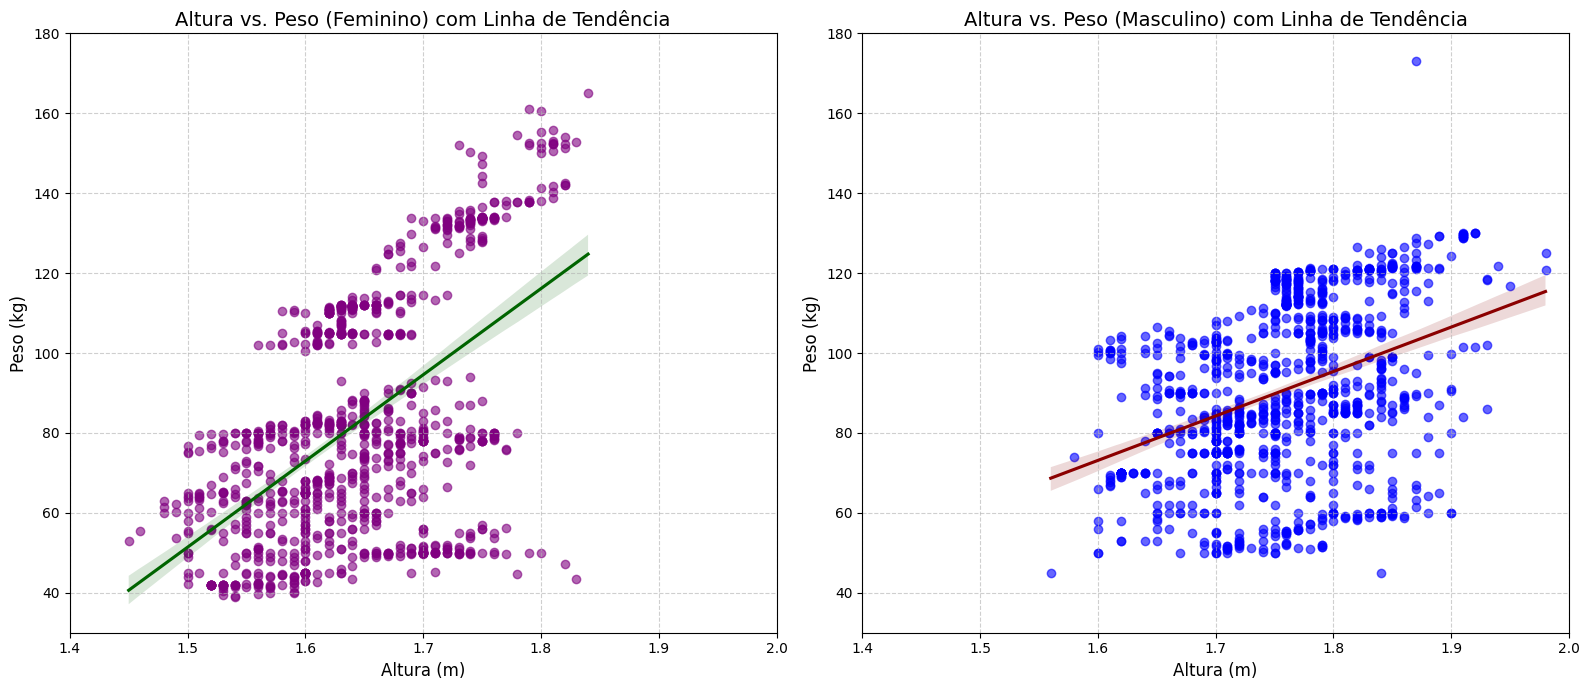

In [25]:
obes_feminino = df_obes[df_obes['sexo'] == 'feminino']
obes_masculino = df_obes[df_obes['sexo'] == 'masculino']

plt.figure(figsize=(16, 7))

# Gráfico para feminino com linha de tendência
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, 1º gráfico
sns.regplot(data=obes_feminino, x='altura(m)', y='peso(kg)', color='purple', scatter_kws={'alpha':0.6}, line_kws={'color':'darkgreen'})
plt.title('Altura vs. Peso (Feminino) com Linha de Tendência', fontsize=14)
plt.xlabel('Altura (m)', fontsize=12)
plt.ylabel('Peso (kg)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(30, 180) # Definir limites do eixo Y para consistência
plt.xlim(1.4, 2.0) # Definir limites do eixo X para consistência

# Gráfico para masculino com linha de tendência
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, 2º gráfico
sns.regplot(data=obes_masculino, x='altura(m)', y='peso(kg)', color='blue', scatter_kws={'alpha':0.6}, line_kws={'color':'darkred'})
plt.title('Altura vs. Peso (Masculino) com Linha de Tendência', fontsize=14)
plt.xlabel('Altura (m)', fontsize=12)
plt.ylabel('Peso (kg)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(30, 180) # Definir limites do eixo Y para consistência
plt.xlim(1.4, 2.0) # Definir limites do eixo X para consistência

plt.tight_layout()
plt.show()

### Análise da Distribuição dos Níveis de Obesidade por Fatores Categóricos

Vamos agora visualizar como cada uma das características categóricas se relaciona com os diferentes níveis de obesidade. Isso nos permitirá identificar quais fatores podem ter maior influência no diagnóstico.

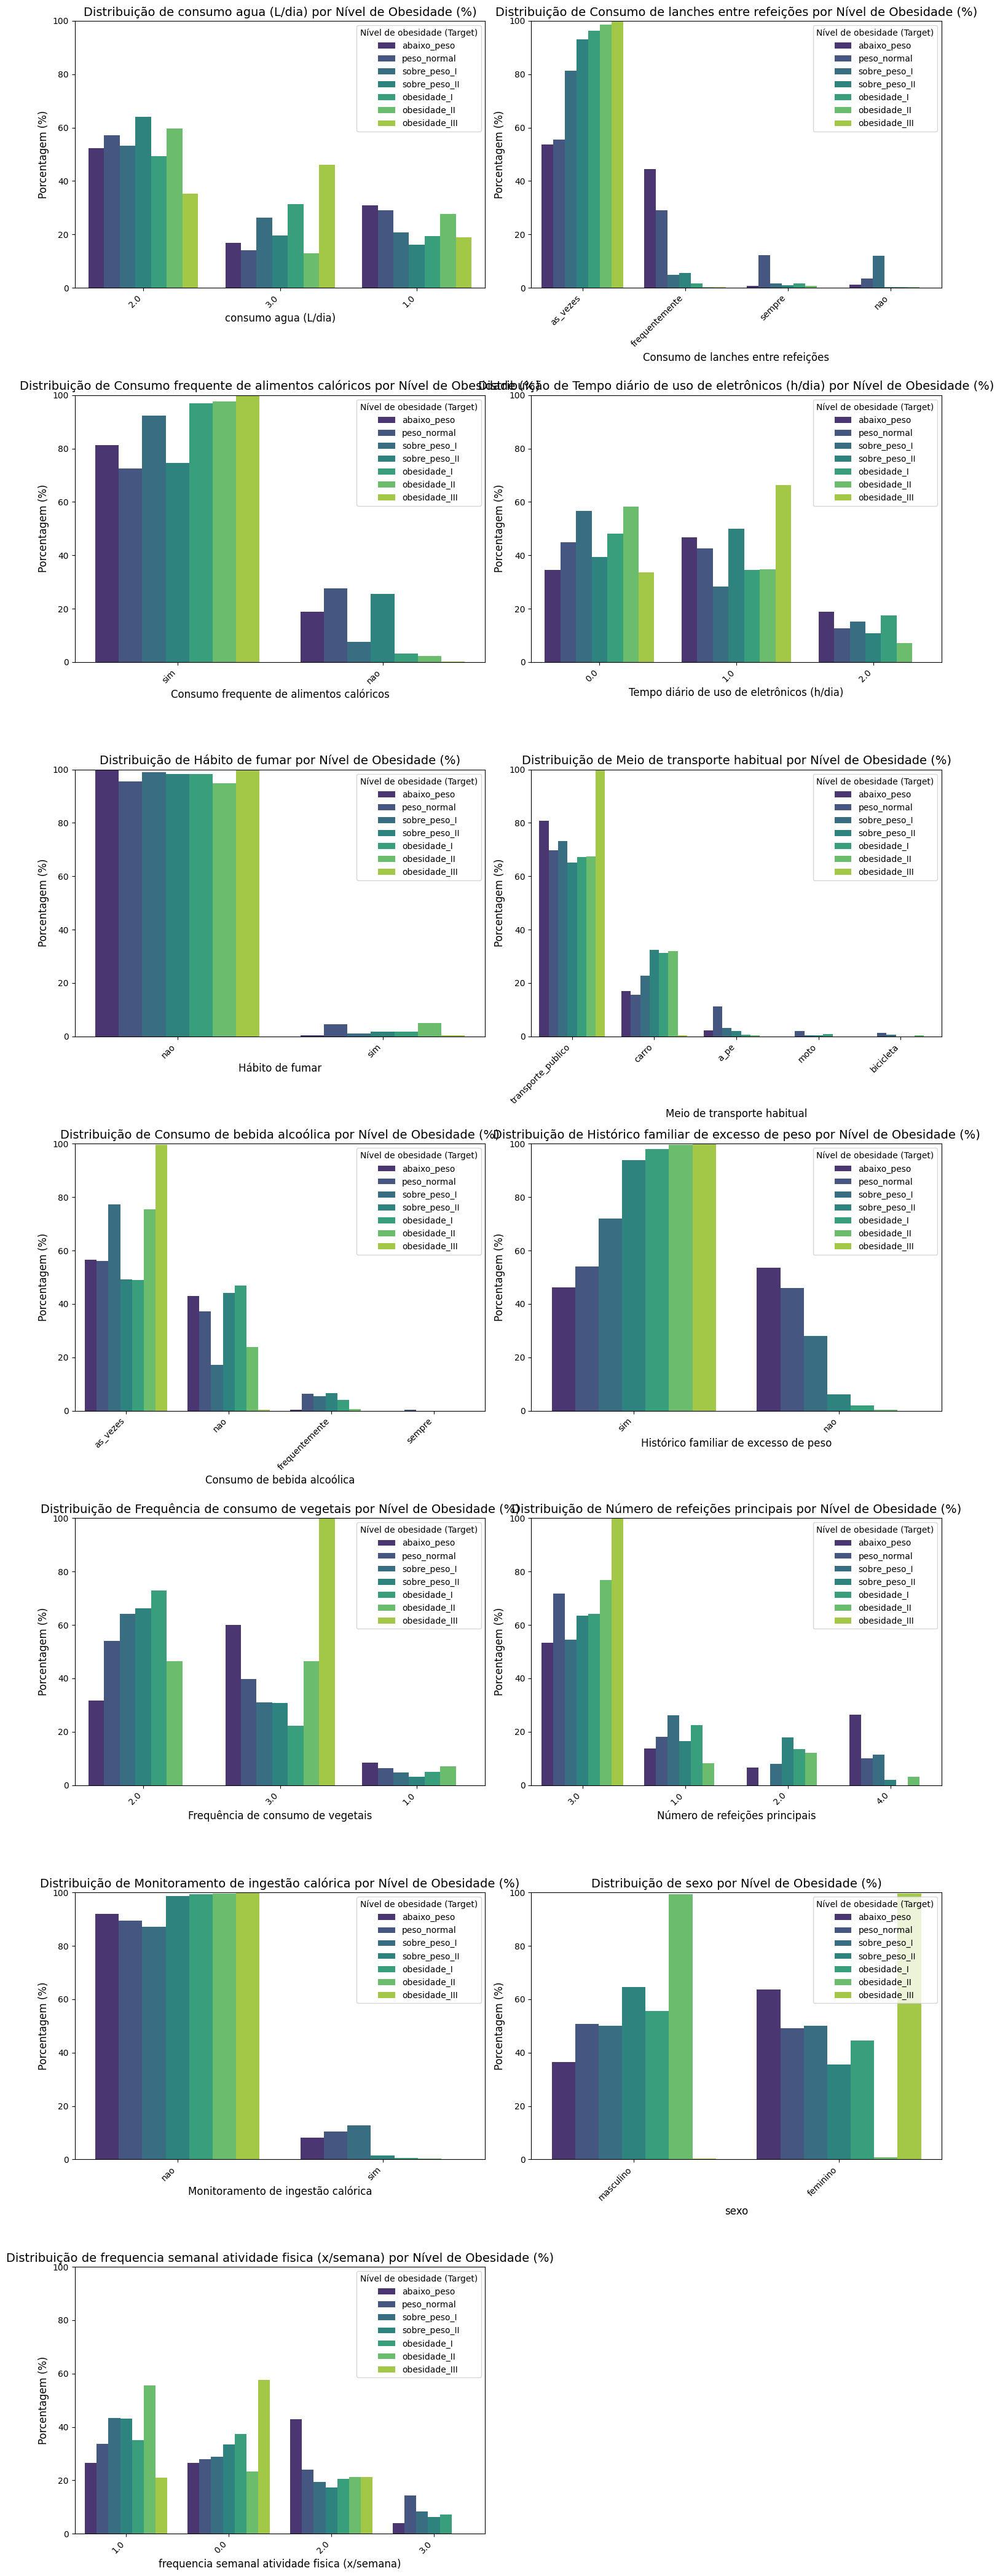

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a consistent order for the target variable for better readability
obesity_order = [
    'abaixo_peso',
    'peso_normal',
    'sobre_peso_I',
    'sobre_peso_II',
    'obesidade_I',
    'obesidade_II',
    'obesidade_III'
]

# Definir as colunas a serem excluídas da plotagem
# Estas já foram analisadas ou são o próprio target
excluded_columns_for_comparison = ['idade(anos)', 'altura(m)', 'peso(kg)', 'Nível de obesidade (Target)', 'IMC']

# Obter as colunas categóricas restantes para plotar, incluindo 'sexo'
columns_to_compare = [col for col in df_obes.columns if col not in excluded_columns_for_comparison and df_obes[col].dtype == 'object']

# Adicionar colunas ordinais que devem ser tratadas como categóricas para esta análise
# As colunas que tinham float e foram arredondadas para inteiros são tratadas como categóricas aqui
ordinal_columns = [
    'Frequência de consumo de vegetais',
    'Número de refeições principais',
    'consumo agua (L/dia)',
    'frequencia semanal atividade fisica (x/semana)',
    'Tempo diário de uso de eletrônicos (h/dia)'
]

columns_to_compare.extend(ordinal_columns)

# Removendo duplicatas, caso alguma coluna já tenha sido adicionada
columns_to_compare = list(set(columns_to_compare))

# Excluir 'Nível de obesidade (Target)' caso tenha sido incluído por engano
if 'Nível de obesidade (Target)' in columns_to_compare:
    columns_to_compare.remove('Nível de obesidade (Target)')


n_cols = 2 # Número de gráficos por linha
n_rows = (len(columns_to_compare) + n_cols - 1) // n_cols # Calcula o número de linhas necessário

plt.figure(figsize=(15, 6 * n_rows))

for i, column in enumerate(columns_to_compare):
    plt.subplot(n_rows, n_cols, i + 1)

    # Calculate percentages for 'Nível de obesidade (Target)' within each 'column' category
    grouped_data = df_obes.groupby('Nível de obesidade (Target)')[column].value_counts(normalize=True).mul(100).rename('percentage').reset_index()

    sns.barplot(data=grouped_data, x=column, y='percentage', hue='Nível de obesidade (Target)', palette='viridis', order=df_obes[column].value_counts().index, hue_order=obesity_order) # Removido legend=False
    plt.title(f'Distribuição de {column} por Nível de Obesidade (%)', fontsize=14)
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Porcentagem (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    sns.move_legend(
    g,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(obesity_order),
    title='Nível de Obesidade'
    )
    plt.ylim(0, 100) # Ensure y-axis goes up to 100%
    # Removed plt.tight_layout() here as it's called outside the loop once.

plt.tight_layout()
plt.show()

Análise Geral dos Gráficos:

Sexo biológico: Observa-se que a distribuição dos níveis de obesidade varia entre os sexos. Em 'masculino', há uma proporção notável de 'sobre_peso_I', 'sobre_peso_II' e 'obesidade_I', enquanto em 'feminino', 'obesidade_II' e 'obesidade_III' são mais proeminentes, sugerindo que o tipo de obesidade pode se manifestar de forma diferente entre homens e mulheres.

Histórico familiar de excesso de peso: Indivíduos com histórico familiar de excesso de peso ('sim') apresentam uma incidência muito maior em todos os níveis de sobrepeso e obesidade, especialmente 'obesidade_I', 'obesidade_II' e 'obesidade_III', do que aqueles sem histórico ('nao'). Isso reforça a importância dos fatores genéticos ou de ambiente familiar.

Consumo frequente de alimentos calóricos (FAVC): Aqueles que consomem frequentemente alimentos calóricos ('sim') mostram uma distribuição pesada nos níveis de obesidade mais elevados ('obesidade_I', 'II', 'III'). Por outro lado, quem diz 'nao' a isso, está mais concentrado em 'peso_normal' ou 'abaixo_peso'.

Frequência de consumo de vegetais: Indivíduos com menor frequência de consumo de vegetais (1.0) tendem a estar mais nos níveis de sobrepeso e obesidade, enquanto aqueles com consumo mais frequente (2.0 ou 3.0) aparecem com mais frequência nas categorias de 'peso_normal'.

Número de refeições principais: A maioria dos indivíduos em todas as categorias de peso tem 3 refeições principais. No entanto, é interessante notar que as categorias de obesidade tendem a ter uma proporção menor de indivíduos com 1 ou 2 refeições, e uma presença considerável de 4 refeições.

Consumo de lanches entre refeições (CAEC): Pessoas que consomem lanches 'às_vezes' ou 'frequentemente' estão distribuídas por todos os níveis de obesidade. Aqueles que 'nao' consomem lanches tendem a ter 'peso_normal' ou 'abaixo_peso'.

Hábito de fumar: A maioria dos indivíduos não fuma. Entre os fumantes ('sim'), a distribuição parece mais variada e não demonstra um padrão claro de influência direta nos níveis de obesidade a partir destes gráficos.

Consumo diário de água (CH2O): Indivíduos que consomem menos água (1.0 L/dia) parecem ter uma tendência maior a níveis de obesidade mais altos, enquanto aqueles que bebem mais água (2.0 ou 3.0 L/dia) estão mais distribuídos entre 'peso_normal' e os diferentes níveis de obesidade.

Monitoramento de ingestão calórica (SCC): A maioria dos indivíduos não monitora a ingestão calórica ('nao'), e estes estão espalhados por todos os níveis de obesidade. Quem monitora ('sim') tem uma distribuição mais notável em 'peso_normal' e 'abaixo_peso', indicando um comportamento mais consciente.

Frequência semanal de atividade física (FAF): Pessoas com menor frequência de atividade física (0.0 ou 1.0 x/semana) estão predominantemente nas categorias de sobrepeso e obesidade. Aqueles com maior frequência (2.0 ou 3.0 x/semana) aparecem mais nas categorias de 'peso_normal' e 'abaixo_peso'.

Tempo diário de uso de eletrônicos (TUE): Quem passa mais tempo em dispositivos eletrônicos (1.0 ou 2.0 h/dia) tende a ter níveis mais altos de obesidade, enquanto aqueles com 0.0 h/dia estão mais concentrados em 'peso_normal' ou 'abaixo_peso'.

Consumo de bebida alcoólica (CALC): O consumo de álcool 'às_vezes' é o mais comum em todas as categorias de peso, não revelando um padrão muito distinto de impacto direto na obesidade a partir destes gráficos.

Meio de transporte habitual (MTRANS): O 'transporte_publico' é o meio mais comum, e é prevalente em todas as categorias de peso. Indivíduos que usam 'carro' também estão presentes em todas as categorias de obesidade, e a 'a_pe' está mais presente nas categorias de 'peso_normal' e 'abaixo_peso'.

Conclusão:

Os gráficos revelam que fatores como histórico familiar, consumo de alimentos calóricos, frequência de consumo de vegetais, frequência de atividade física e tempo de uso de eletrônicos mostram as relações mais claras e fortes com os diferentes níveis de obesidade. Estes são pontos cruciais a serem considerados no desenvolvimento do modelo preditivo e nas intervenções de saúde.


PROXIMOS INSIGHTS:



1.   CALCULAR IMC
2.   FAF × TUE → Perfil "Duplamente Sedentário"
3.   FAVC × CAEC → Sobrecarga Calórica Comportamental
4.   family_history × FAVC → Genética + Comportamento
5.   NCP × CAEC → Padrão Alimentar Paradoxal
6.   SCC × FAF → Consciência vs. Ação
7.   MTRANS × FAF → Sedentarismo Estrutural

extras:

Gender × FAF: Mulheres e homens respondem igual ao sedentarismo?

Gender × Age: Em que idade homens e mulheres atingem o pico de obesidade?






In [27]:
## analisando o IMC entre mulheres e homens e idade

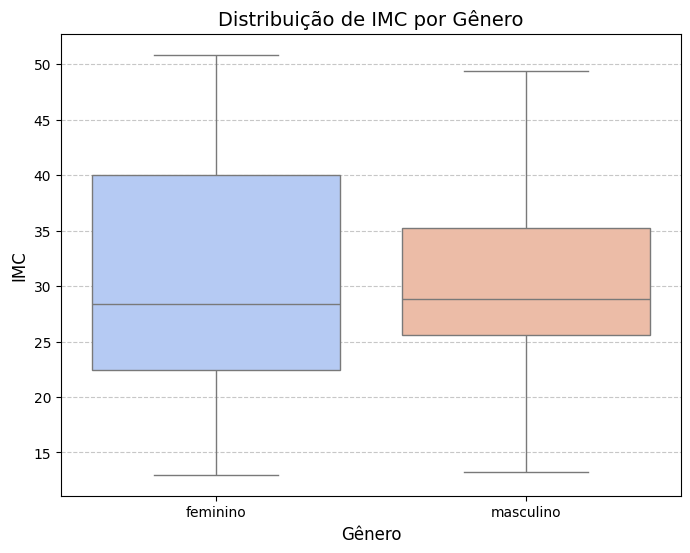

In [28]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_obes, x='sexo', y='IMC', hue='sexo', palette='coolwarm')
plt.title('Distribuição de IMC por Gênero', fontsize=14)
plt.xlabel('Gênero', fontsize=12)
plt.ylabel('IMC', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

FREQUENCIA DE ATIVIDADE FISICA X TEMPO DE USO DE ELETRONICOS, COM COMPARAÇÃO AO "NIVEL DE OBESIDADE"

NO PLOT DO SEABORN, NÃO GEROU DADOS PARA AS DUAS COMBINAÇÕES

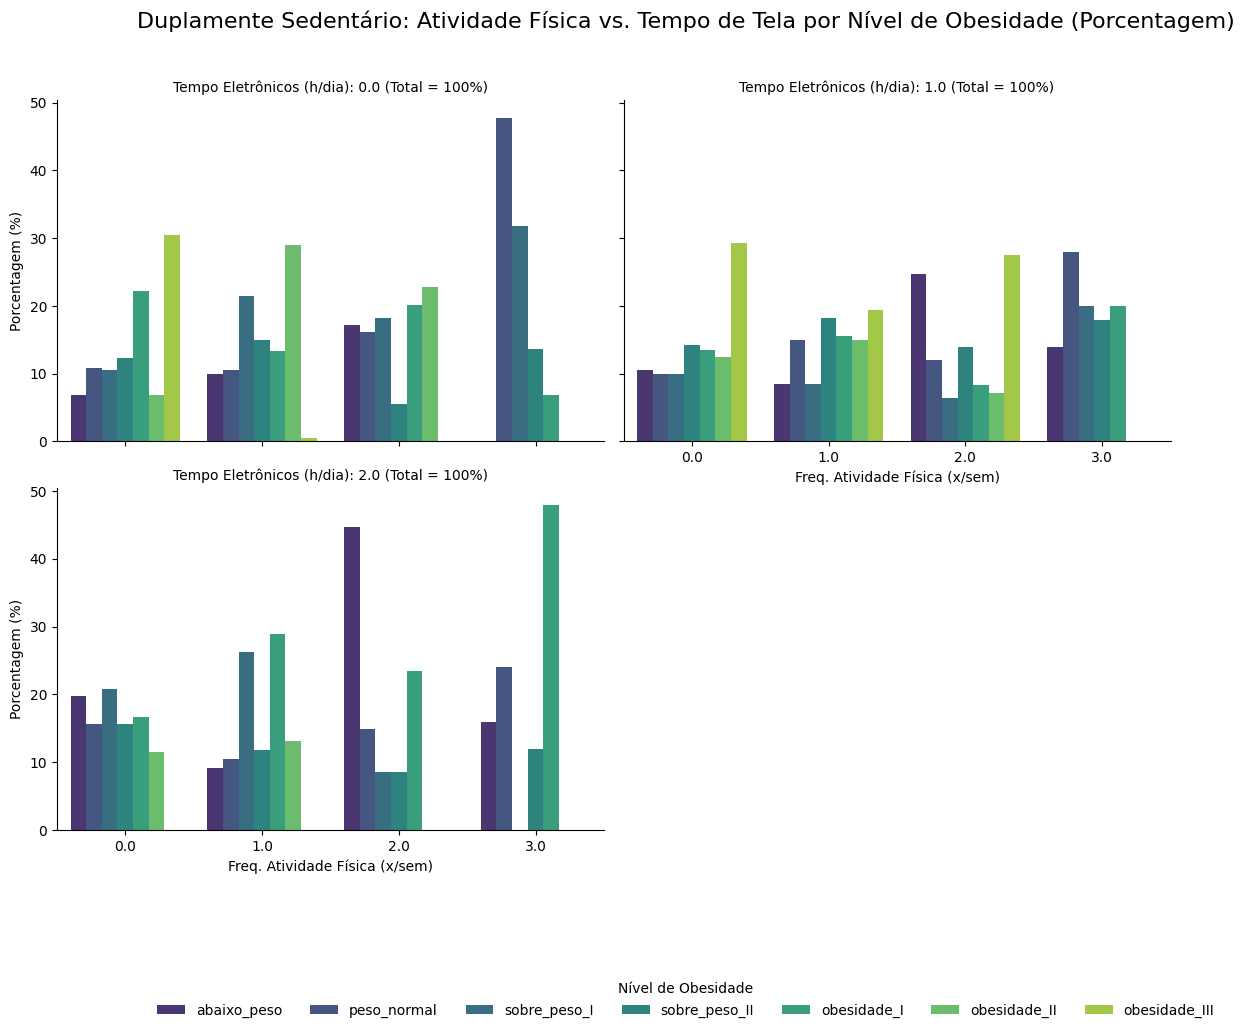

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a consistent order for the target variable for better readability
obesity_order = [
    'abaixo_peso',
    'peso_normal',
    'sobre_peso_I',
    'sobre_peso_II',
    'obesidade_I',
    'obesidade_II',
    'obesidade_III'
]

# Plot 1: "Duplamente Sedentario"

group_cols_for_percentages = ['Tempo diário de uso de eletrônicos (h/dia)', 'frequencia semanal atividade fisica (x/semana)']
percentage_data = df_obes.groupby(group_cols_for_percentages)['Nível de obesidade (Target)'].value_counts(normalize=True).mul(100).rename('percentage').reset_index()

# Removed plt.figure(figsize=(15, 8)) as catplot creates its own figure
g = sns.catplot(
    data=percentage_data,
    x='frequencia semanal atividade fisica (x/semana)',
    y='percentage',
    hue='Nível de obesidade (Target)',
    col='Tempo diário de uso de eletrônicos (h/dia)',
    kind='bar',
    palette='viridis',
    height=5, aspect=1.2,
    col_wrap=2,
    order=sorted(df_obes['frequencia semanal atividade fisica (x/semana)'].unique()),
    hue_order=obesity_order,
    col_order=sorted(df_obes['Tempo diário de uso de eletrônicos (h/dia)'].unique()),

)
g.set_axis_labels("Freq. Atividade Física (x/sem)", "Porcentagem (%)")
g.set_titles("Tempo Eletrônicos (h/dia): {col_name} (Total = 100%)")
g.fig.suptitle('Duplamente Sedentário: Atividade Física vs. Tempo de Tela por Nível de Obesidade (Porcentagem)', y=1.02, fontsize=16)

sns.move_legend(
    g,
    loc='lower center',
    bbox_to_anchor=(0.5, 0),
    ncol=len(obesity_order),
    title='Nível de Obesidade'
)
g.fig.subplots_adjust(top=0.93, bottom=0.20)
plt.show()

FREQUENCIA ALTA INGESTÃO DE ALIMENTOS CALÓRICOS X CONSUMO DE LANCHES ENTRE REFEIÇÕES, COM COMPARAÇÃO AO "NIVEL DE OBESIDADE"

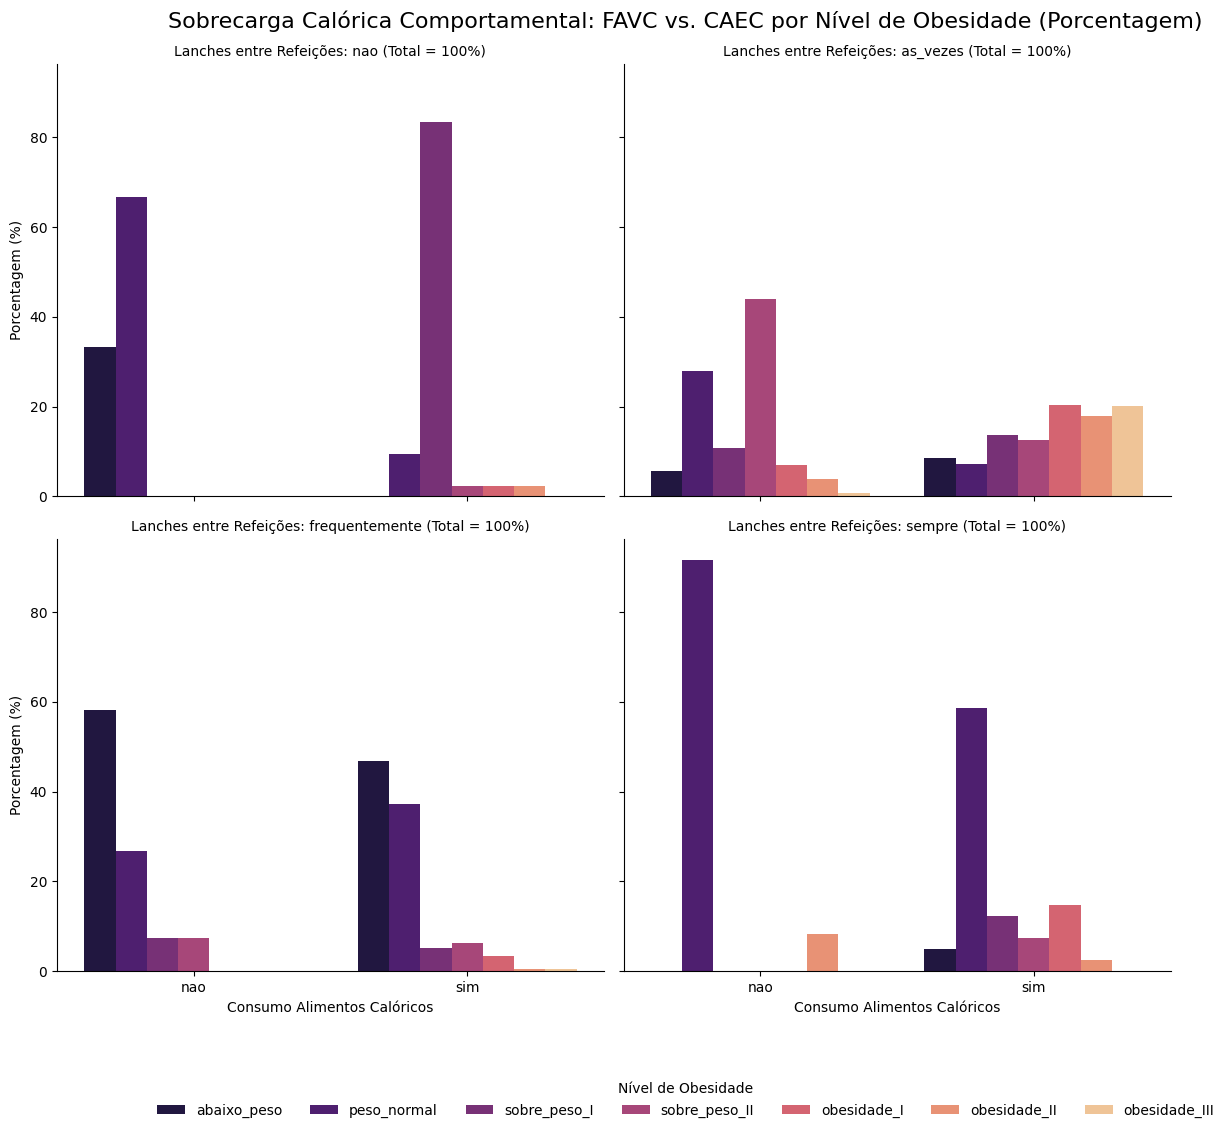

In [60]:
# Plot 2: "Sobrecarga Calórica Comportamental"
obesity_order = [
    'abaixo_peso', 'peso_normal', 'sobre_peso_I', 'sobre_peso_II',
    'obesidade_I', 'obesidade_II', 'obesidade_III'
]

group_cols_for_percentages = ['Consumo de lanches entre refeições', 'Consumo frequente de alimentos calóricos']
percentage_data = df_obes.groupby(group_cols_for_percentages)['Nível de obesidade (Target)'].value_counts(normalize=True).mul(100).rename('percentage').reset_index()

# Removed plt.figure(figsize=(15, 8)) as catplot creates its own figure
g = sns.catplot(
    data=percentage_data,
    x='Consumo frequente de alimentos calóricos',
    y='percentage',
    hue='Nível de obesidade (Target)',
    col='Consumo de lanches entre refeições',
    kind='bar',
    palette='magma',
    height=5, aspect=1.2,
    col_wrap=2,
    hue_order=obesity_order,
    col_order=['nao', 'as_vezes', 'frequentemente', 'sempre'],
    order=['nao', 'sim'],

)
g.set_axis_labels("Consumo Alimentos Calóricos", "Porcentagem (%)")
g.set_titles("Lanches entre Refeições: {col_name} (Total = 100%)")
g.fig.suptitle('Sobrecarga Calórica Comportamental: FAVC vs. CAEC por Nível de Obesidade (Porcentagem)', y=1.02, fontsize=16)

sns.move_legend(
    g,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(obesity_order),
    title='Nível de Obesidade'
)
plt.show()

HISTORICO FAMILIAR X FREQUENCIA DE ALIMENTOS ALTAMENTE CALORICOS, COM COMPARAÇÃO AO "NIVEL DE OBESIDADE"

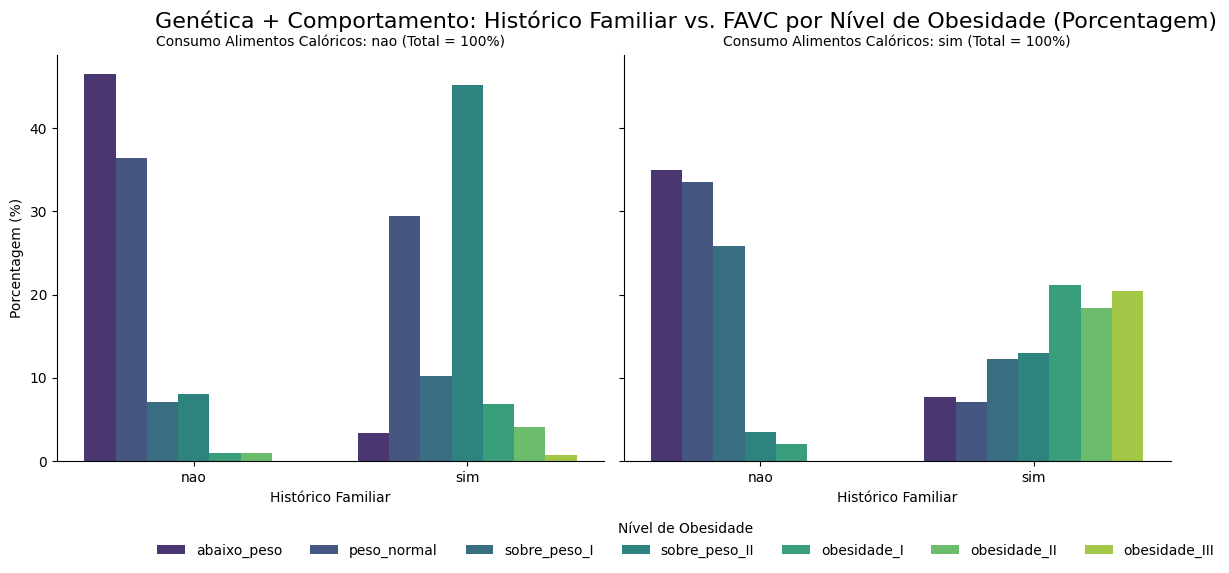

In [61]:
# Plot 3: "Genética + Comportamento"
obesity_order = [
    'abaixo_peso', 'peso_normal', 'sobre_peso_I', 'sobre_peso_II',
    'obesidade_I', 'obesidade_II', 'obesidade_III'
]

group_cols_for_percentages = ['Consumo frequente de alimentos calóricos', 'Histórico familiar de excesso de peso']
percentage_data = df_obes.groupby(group_cols_for_percentages)['Nível de obesidade (Target)'].value_counts(normalize=True).mul(100).rename('percentage').reset_index()

# Removed plt.figure(figsize=(15, 8)) as catplot creates its own figure
g = sns.catplot(
    data=percentage_data,
    x='Histórico familiar de excesso de peso',
    y='percentage',
    hue='Nível de obesidade (Target)',
    col='Consumo frequente de alimentos calóricos',
    kind='bar',
    palette='viridis',
    height=5, aspect=1.2,
    col_wrap=2,
    hue_order=obesity_order,
    col_order=['nao', 'sim'],
    order=['nao', 'sim'],

)
g.set_axis_labels("Histórico Familiar", "Porcentagem (%)")
g.set_titles("Consumo Alimentos Calóricos: {col_name} (Total = 100%)")
g.fig.suptitle('Genética + Comportamento: Histórico Familiar vs. FAVC por Nível de Obesidade (Porcentagem)', y=1.02, fontsize=16)

sns.move_legend(
    g,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(obesity_order),
    title='Nível de Obesidade'
)

plt.show()

REFEIÇÕES PRINCIPAIS X LANCHES DURANTE AS REFEIÇÕES, COM COMPARAÇÃO AO "NIVEL DE OBESIDADE"

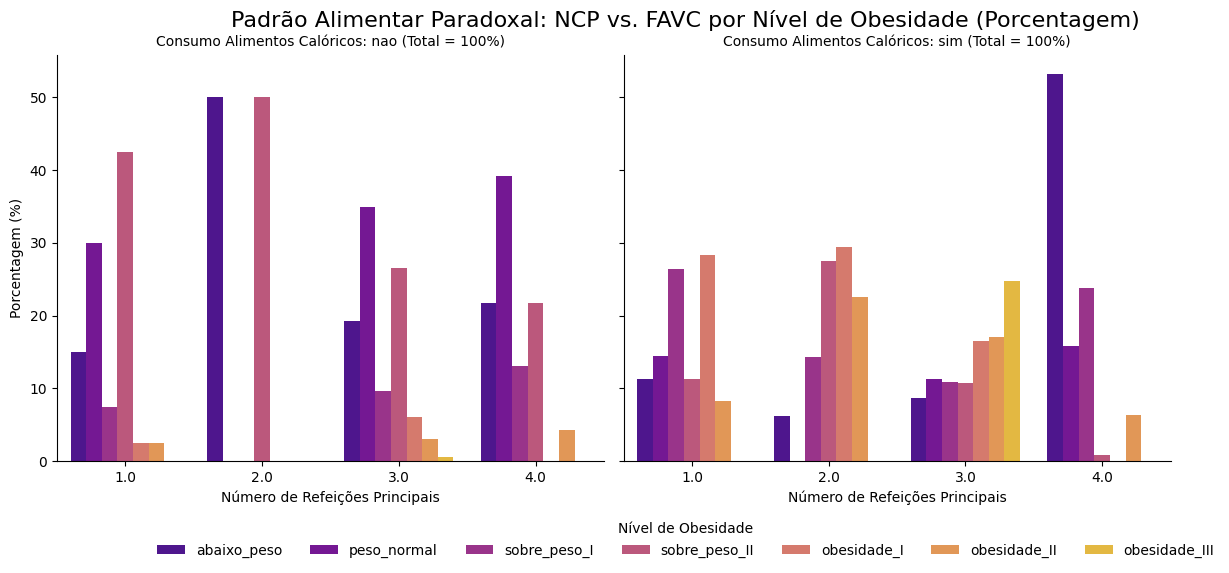

In [88]:
# Plot 4: "Padrão Alimentar Paradoxal"
obesity_order = [
    'abaixo_peso', 'peso_normal', 'sobre_peso_I', 'sobre_peso_II',
    'obesidade_I', 'obesidade_II', 'obesidade_III'
]

group_cols_for_percentages = ['Consumo frequente de alimentos calóricos', 'Número de refeições principais']
percentage_data = df_obes.groupby(group_cols_for_percentages)['Nível de obesidade (Target)'].value_counts(normalize=True).mul(100).rename('percentage').reset_index()

# Removed plt.figure(figsize=(15, 8)) as catplot creates its own figure
g = sns.catplot(
    data=percentage_data,
    x='Número de refeições principais',
    y='percentage',
    hue='Nível de obesidade (Target)',
    col='Consumo frequente de alimentos calóricos',
    kind='bar',
    palette='plasma',
    height=5, aspect=1.2,
    col_wrap=2,
    order=sorted(df_obes['Número de refeições principais'].unique()),
    hue_order=obesity_order,
    col_order=['nao', 'sim'],

)
g.set_axis_labels("Número de Refeições Principais", "Porcentagem (%)")
g.set_titles("Consumo Alimentos Calóricos: {col_name} (Total = 100%)")
g.fig.suptitle('Padrão Alimentar Paradoxal: NCP vs. FAVC por Nível de Obesidade (Porcentagem)', y=1.02, fontsize=16)
sns.move_legend(
    g,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(obesity_order),
    title='Nível de Obesidade'
)
plt.show()

### Padrão Alimentar Paradoxal: Número de Refeições Principais (NCP) vs. Consumo de Lanches entre Refeições (CAEC)

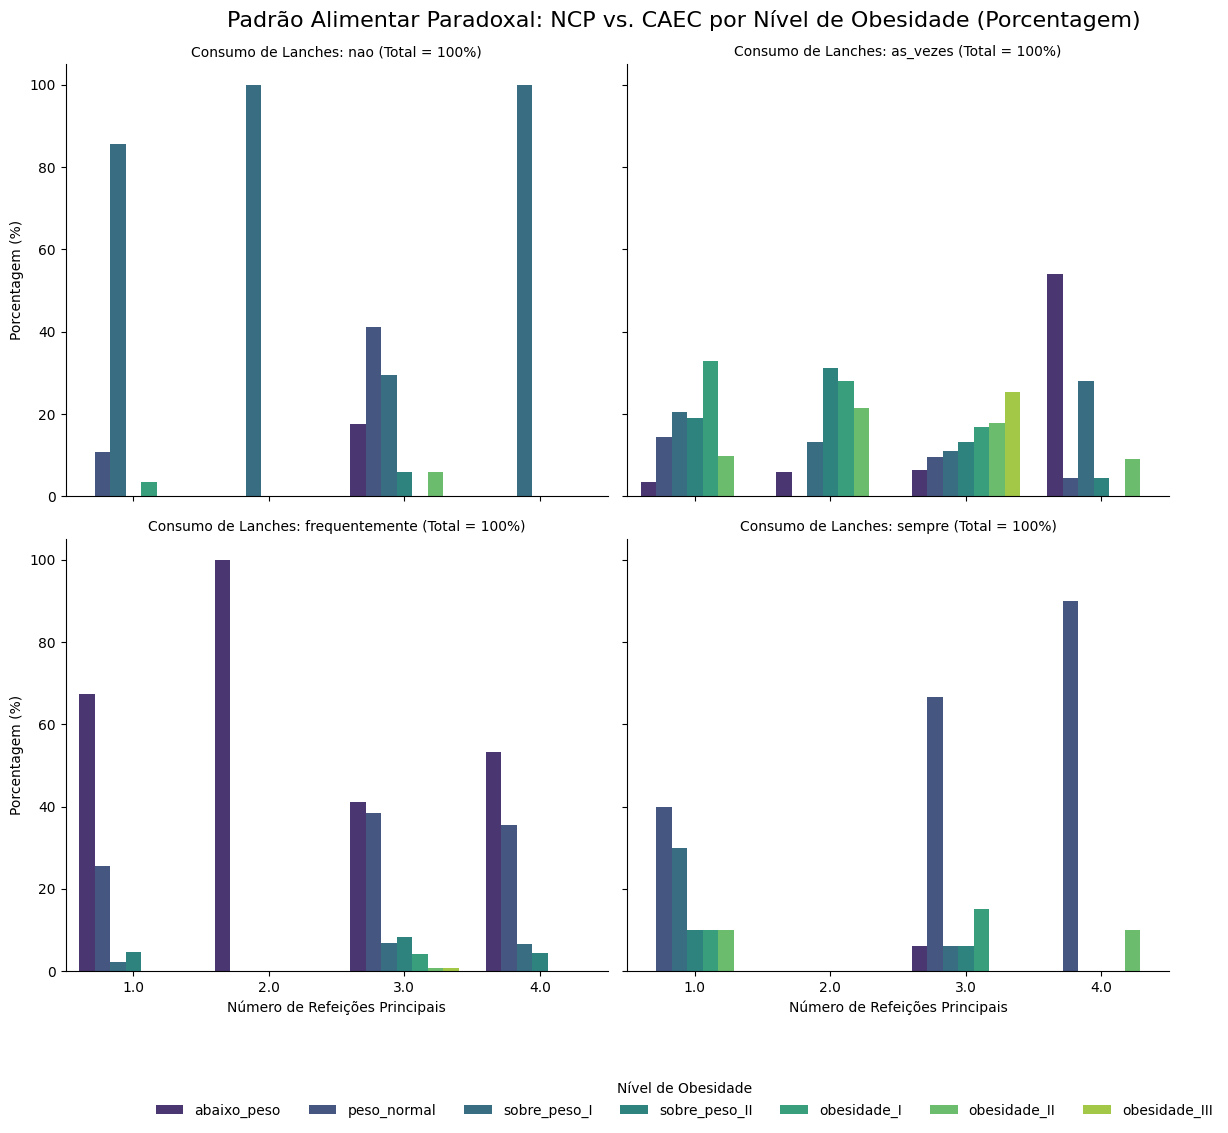

In [89]:
# Novo Plot: "Padrão Alimentar Paradoxal" - NCP vs CAEC por Nível de Obesidade
obesity_order = [
    'abaixo_peso', 'peso_normal', 'sobre_peso_I', 'sobre_peso_II',
    'obesidade_I', 'obesidade_II', 'obesidade_III'
]

group_cols_for_percentages = ['Consumo de lanches entre refeições', 'Número de refeições principais']
percentage_data = df_obes.groupby(group_cols_for_percentages)['Nível de obesidade (Target)'].value_counts(normalize=True).mul(100).rename('percentage').reset_index()

g = sns.catplot(
    data=percentage_data,
    x='Número de refeições principais',
    y='percentage',
    hue='Nível de obesidade (Target)',
    col='Consumo de lanches entre refeições',
    kind='bar',
    palette='viridis',
    height=5, aspect=1.2,
    col_wrap=2,
    order=sorted(df_obes['Número de refeições principais'].unique()),
    hue_order=obesity_order,
    col_order=['nao', 'as_vezes', 'frequentemente', 'sempre'],

)
g.set_axis_labels("Número de Refeições Principais", "Porcentagem (%)")
g.set_titles("Consumo de Lanches: {col_name} (Total = 100%)")
g.fig.suptitle('Padrão Alimentar Paradoxal: NCP vs. CAEC por Nível de Obesidade (Porcentagem)', y=1.02, fontsize=16)
sns.move_legend(
    g,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(obesity_order),
    title='Nível de Obesidade'
)
plt.show()

### Padrão Alimentar Paradoxal por Nível de Obesidade e Gênero: Número de Refeições Principais (NCP) vs. Consumo de Lanches entre Refeições (CAEC)

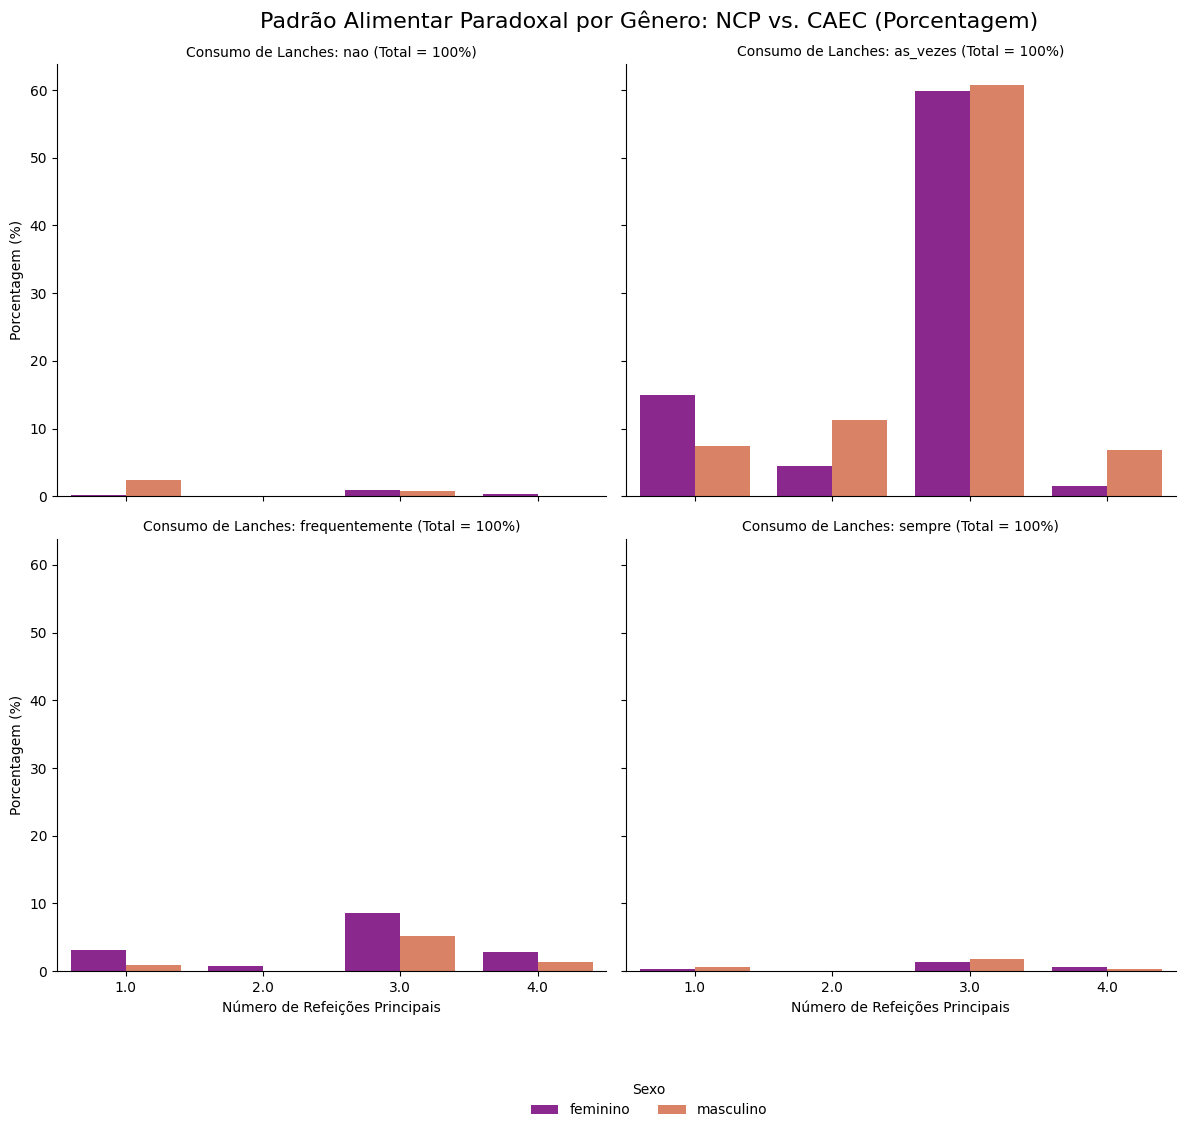

In [115]:
# Novo Plot: "Padrão Alimentar Paradoxal" - NCP vs CAEC por Gênero
sexo_order = ['feminino', 'masculino']
obesity_order = [
    'abaixo_peso', 'peso_normal', 'sobre_peso_I', 'sobre_peso_II',
    'obesidade_I', 'obesidade_II', 'obesidade_III'
]

group_cols_for_percentages = ['Consumo de lanches entre refeições', 'Número de refeições principais']
percentage_data = df_obes.groupby('sexo')[group_cols_for_percentages].value_counts(normalize=True).mul(100).rename('percentage').reset_index()

g = sns.catplot(
    data=percentage_data,
    x='Número de refeições principais',
    y='percentage',
    hue='sexo',
    col='Consumo de lanches entre refeições',
    kind='bar',
    palette='plasma',
    height=5, aspect=1.2,
    col_wrap=2,
    order=sorted(df_obes['Número de refeições principais'].unique()),
    hue_order=sexo_order,
    col_order=['nao', 'as_vezes', 'frequentemente', 'sempre'],

)
g.set_axis_labels("Número de Refeições Principais", "Porcentagem (%)")
g.set_titles("Consumo de Lanches: {col_name} (Total = 100%)")
g.fig.suptitle('Padrão Alimentar Paradoxal por Gênero: NCP vs. CAEC (Porcentagem)', y=1.02, fontsize=16)
sns.move_legend(
    g,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(obesity_order),
    title='Sexo'
)
plt.show()

### Análise da Distribuição de Níveis de Obesidade por Idade e Gênero

/tmp/ipykernel_578/290073687.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  percentage_data_idade = df_obes.groupby(['faixa_etaria', 'sexo'])['Nível de obesidade (Target)'].value_counts(normalize=True).mul(100).rename('percentage').reset_index()


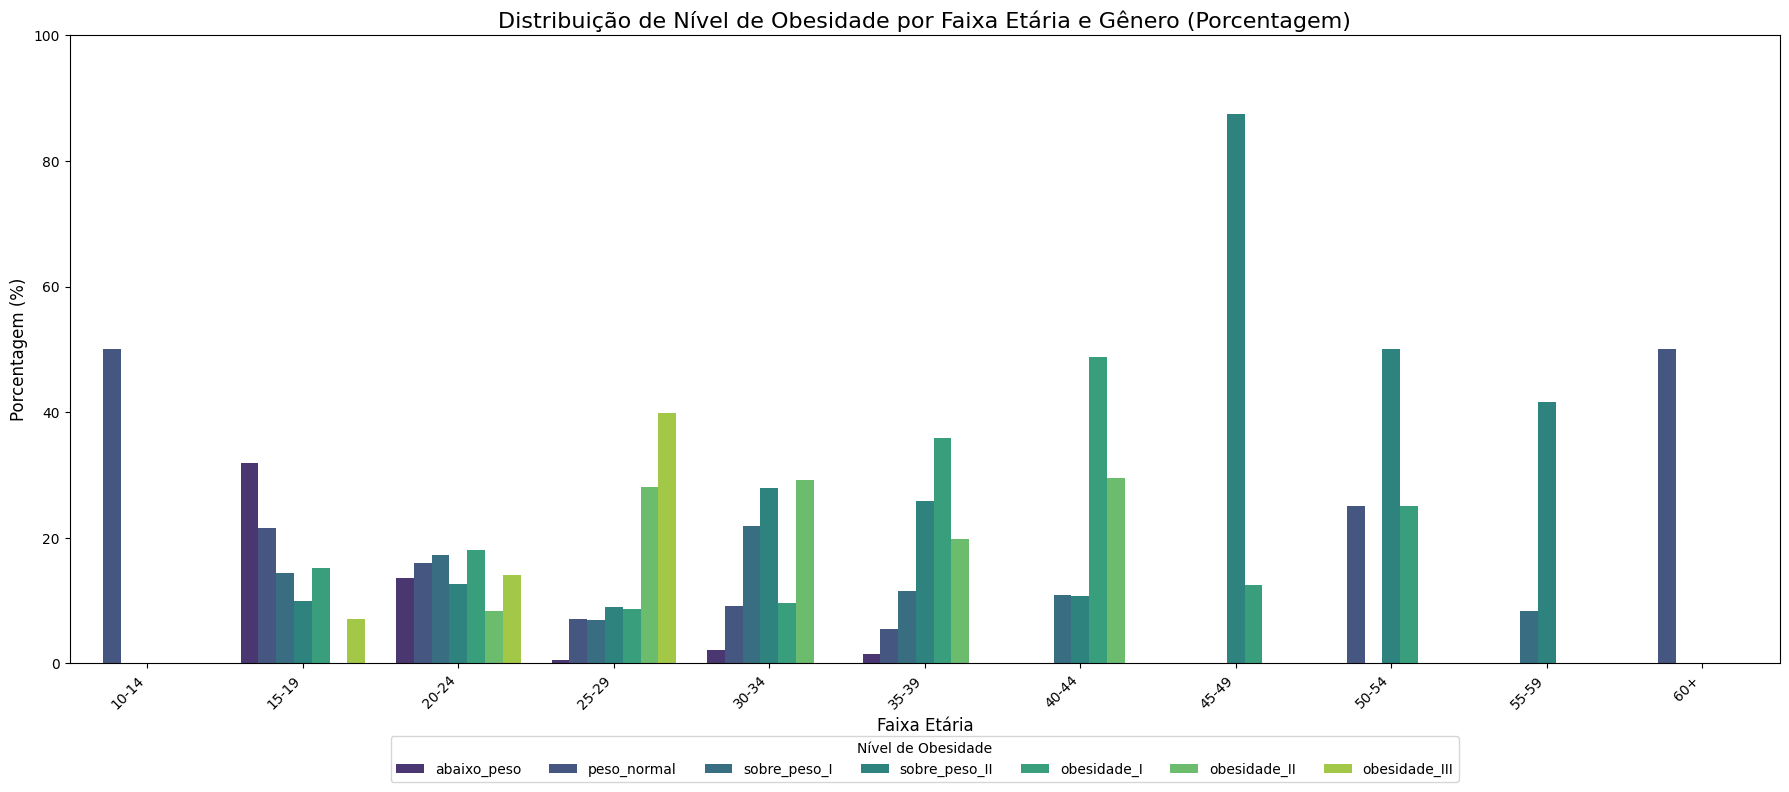

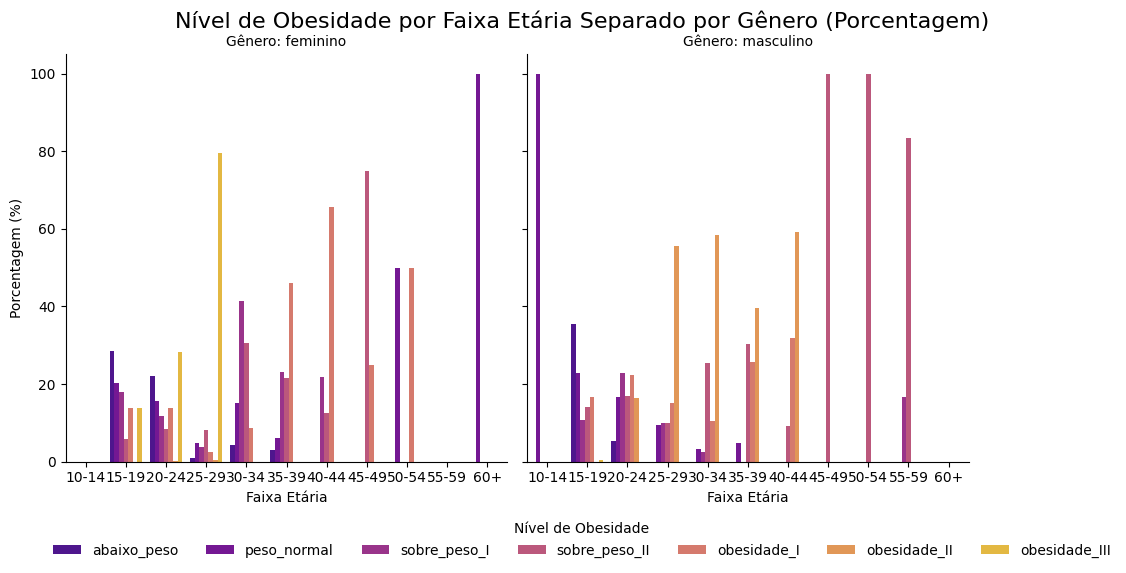

In [66]:
# Analise de 'Gender x Age': Em que idade homens e mulheres atingem o pico de obesidade?

# Criar bins de idade
idade_bins = [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, df_obes['idade(anos)'].max() + 1]
idade_labels = ['10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60+']
df_obes['faixa_etaria'] = pd.cut(df_obes['idade(anos)'], bins=idade_bins, labels=idade_labels, right=False)

# Calcular porcentagens de Nível de Obesidade por Faixa Etária e Gênero
percentage_data_idade = df_obes.groupby(['faixa_etaria', 'sexo'])['Nível de obesidade (Target)'].value_counts(normalize=True).mul(100).rename('percentage').reset_index()

obesity_order = [
    'abaixo_peso', 'peso_normal', 'sobre_peso_I', 'sobre_peso_II',
    'obesidade_I', 'obesidade_II', 'obesidade_III'
]

plt.figure(figsize=(18, 8))
sns.barplot(
    data=percentage_data_idade,
    x='faixa_etaria',
    y='percentage',
    hue='Nível de obesidade (Target)',
    palette='viridis',
    hue_order=obesity_order,
    errorbar=None # Remove error bars for clarity
)
plt.title('Distribuição de Nível de Obesidade por Faixa Etária e Gênero (Porcentagem)', fontsize=16)
plt.xlabel('Faixa Etária', fontsize=12)
plt.ylabel('Porcentagem (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.legend(title='Nível de Obesidade', loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(obesity_order))
plt.tight_layout()
plt.show()

# Corrected catplot call
g = sns.catplot(
    data=percentage_data_idade,
    x='faixa_etaria',
    y='percentage',
    hue='Nível de obesidade (Target)',
    col='sexo',
    kind='bar',
    palette='plasma',
    col_wrap=2,
    col_order=['feminino', 'masculino'],
    hue_order=obesity_order,

)
g.set_axis_labels("Faixa Etária", "Porcentagem (%)")
g.set_titles("Gênero: {col_name}")
g.fig.suptitle('Nível de Obesidade por Faixa Etária Separado por Gênero (Porcentagem)', y=1.02, fontsize=16)
sns.move_legend(
    g,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(obesity_order),
    title='Nível de Obesidade'
)
plt.show()

FREQUENCIA DE ATIVIDADE FISICA X MONITORIAMENTO DE CALORIAS, COM COMPARAÇÃO AO "NIVEL DE OBESIDADE"

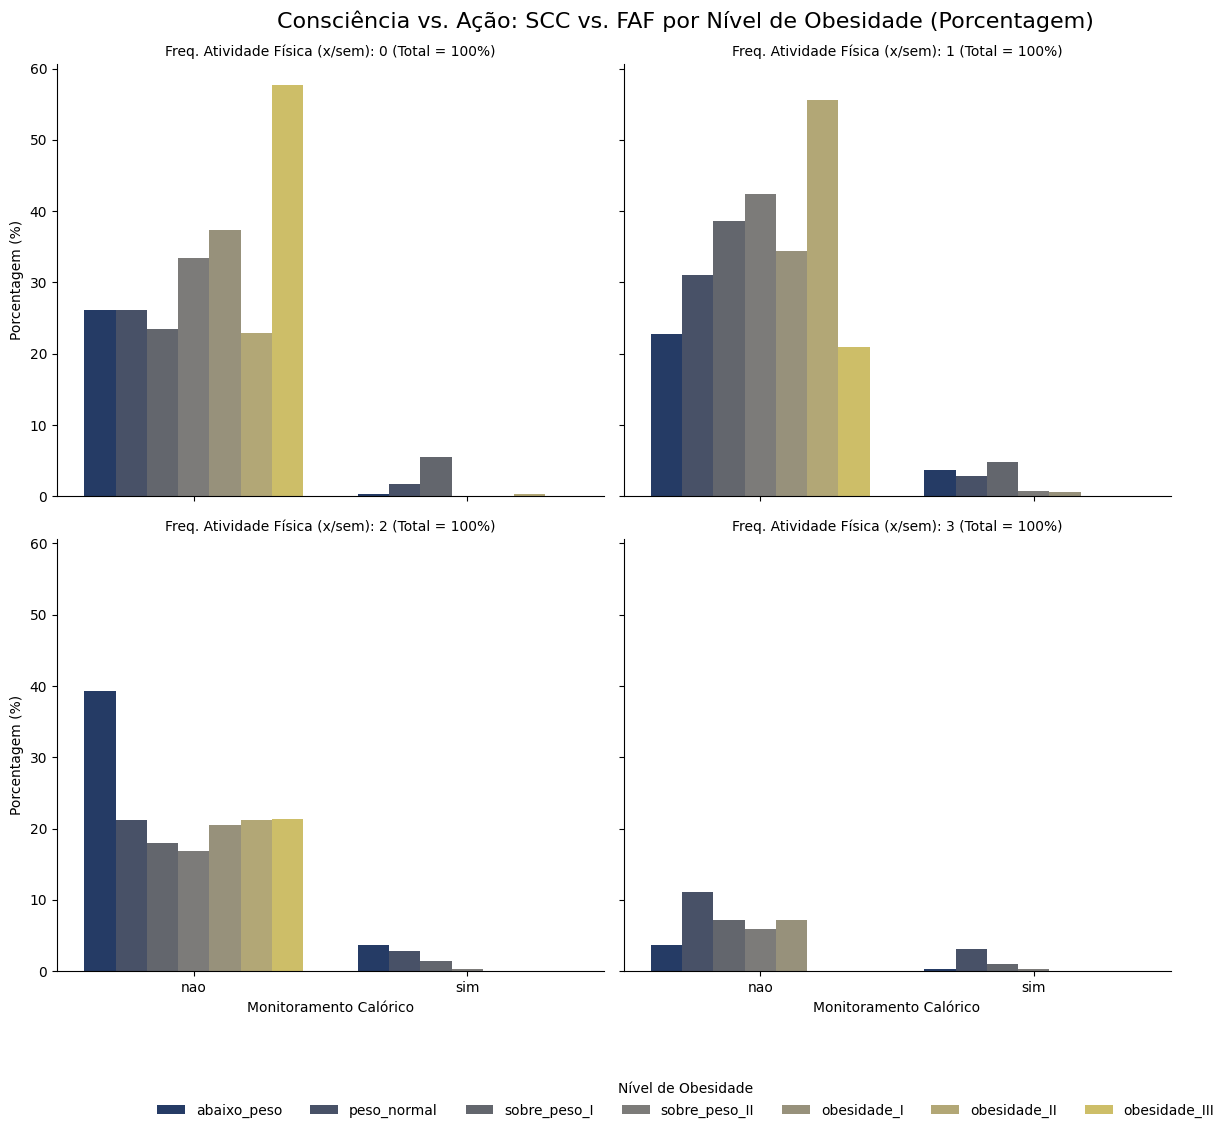

In [116]:
# Plot 5: "Consciência vs. Ação"
obesity_order = [
    'abaixo_peso', 'peso_normal', 'sobre_peso_I', 'sobre_peso_II',
    'obesidade_I', 'obesidade_II', 'obesidade_III'
]

group_cols_for_percentages = ['Monitoramento de ingestão calórica', 'frequencia semanal atividade fisica (x/semana)']
percentage_data = df_obes.groupby('Nível de obesidade (Target)')[group_cols_for_percentages].value_counts(normalize=True).mul(100).rename('percentage').reset_index()

# Removed plt.figure(figsize=(15, 8)) as catplot creates its own figure
g = sns.catplot(
    data=percentage_data,
    x='Monitoramento de ingestão calórica',
    y='percentage',
    hue='Nível de obesidade (Target)',
    col='frequencia semanal atividade fisica (x/semana)',
    kind='bar',
    palette='cividis',
    height=5, aspect=1.2,
    col_wrap=2,
    hue_order=obesity_order,
    col_order=[0, 1, 2, 3],
    order=['nao', 'sim'],

)
g.set_axis_labels("Monitoramento Calórico", "Porcentagem (%)")
g.set_titles("Freq. Atividade Física (x/sem): {col_name} (Total = 100%)")
g.fig.suptitle('Consciência vs. Ação: SCC vs. FAF por Nível de Obesidade (Porcentagem)', y=1.02, fontsize=16)
sns.move_legend(
    g,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(obesity_order),
    title='Nível de Obesidade'
)
plt.show()

USO DE TRANSPORTE X FREQUENCIA DE ATIVIDADE FISICA, COM COMPARAÇÃO AO "NIVEL DE OBESIDADE"

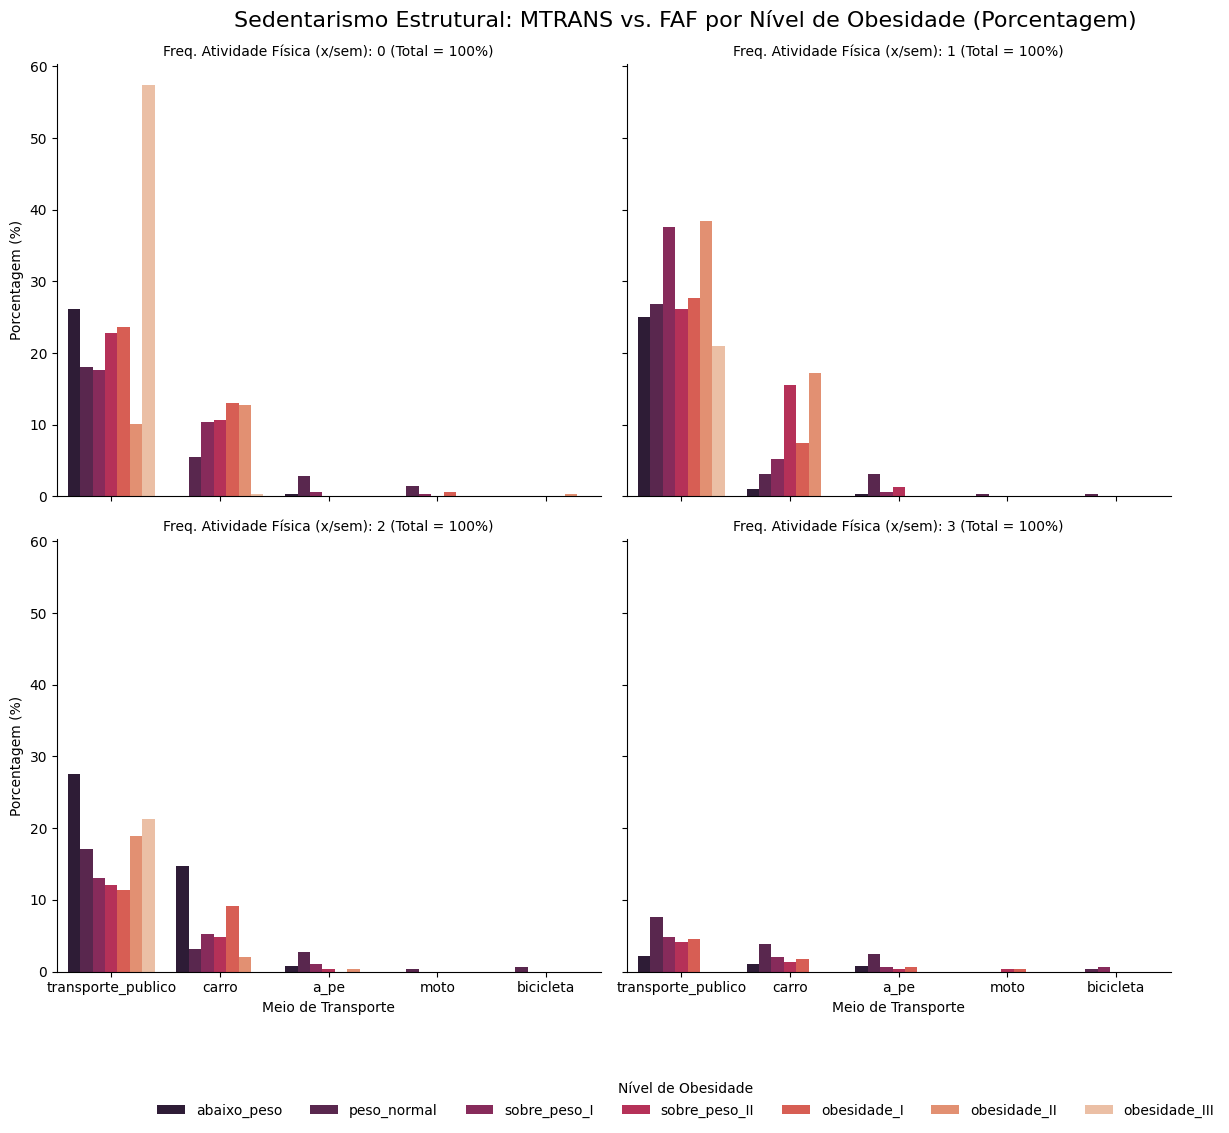

In [120]:
# Plot 6: "Sedentarismo Estrutural"
obesity_order = [
    'abaixo_peso', 'peso_normal', 'sobre_peso_I', 'sobre_peso_II',
    'obesidade_I', 'obesidade_II', 'obesidade_III'
]

group_cols_for_percentages = ['frequencia semanal atividade fisica (x/semana)', 'Meio de transporte habitual']
percentage_data = df_obes.groupby('Nível de obesidade (Target)')[group_cols_for_percentages].value_counts(normalize=True).mul(100).rename('percentage').reset_index()

# Removed plt.figure(figsize=(15, 8)) as catplot creates its own figure
g = sns.catplot(
    data=percentage_data,
    x='Meio de transporte habitual',
    y='percentage',
    hue='Nível de obesidade (Target)',
    col='frequencia semanal atividade fisica (x/semana)',
    kind='bar',
    palette='rocket',
    height=5, aspect=1.2,
    col_wrap=2,
    hue_order=obesity_order,
    col_order=[0, 1, 2, 3],
    order=['transporte_publico', 'carro', 'a_pe', 'moto', 'bicicleta'],

)
g.set_axis_labels("Meio de Transporte", "Porcentagem (%)")
g.set_titles("Freq. Atividade Física (x/sem): {col_name} (Total = 100%)")
g.fig.suptitle('Sedentarismo Estrutural: MTRANS vs. FAF por Nível de Obesidade (Porcentagem)', y=1.02, fontsize=16)
sns.move_legend(
    g,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(obesity_order),
    title='Nível de Obesidade'
)
plt.show()

### Análise Comparativa por Gênero para Níveis de Obesidade

Vamos refazer os gráficos comparativos, mas agora usando o 'sexo' como a variável `hue` principal, e o 'Nível de obesidade (Target)' como as colunas facetadas, para entender melhor as diferenças de gênero dentro de cada categoria de obesidade.

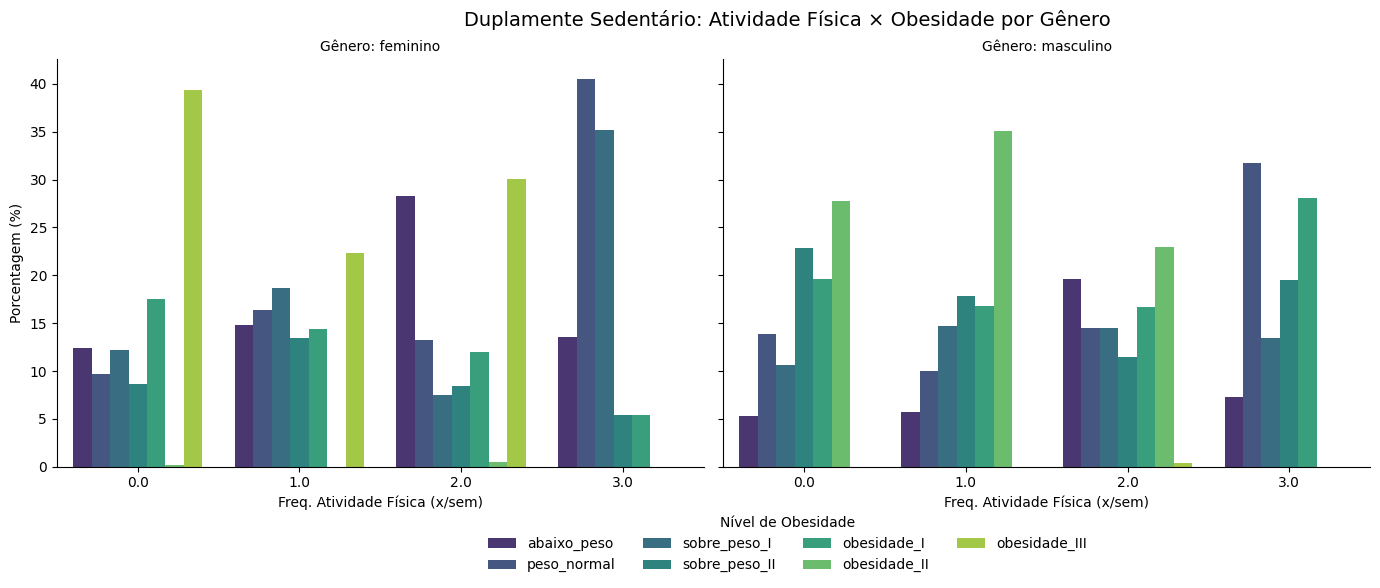

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define consistent order for gender for consistent coloring
sexo_order = ['feminino', 'masculino']
obesity_order = [
    'abaixo_peso',
    'peso_normal',
    'sobre_peso_I',
    'sobre_peso_II',
    'obesidade_I',
    'obesidade_II',
    'obesidade_III'
]

# Plot 1: "Duplamente Sedentário" por Nível de Obesidade e Gênero
percentage_data = (
    df_obes.groupby(['sexo', 'frequencia semanal atividade fisica (x/semana)'])
    ['Nível de obesidade (Target)']
    .value_counts(normalize=True).mul(100)
    .rename('percentage').reset_index()
)
g = sns.catplot(
    data=percentage_data,
    x='frequencia semanal atividade fisica (x/semana)',
    y='percentage',
    hue='Nível de obesidade (Target)',
    col='sexo',
    kind='bar',
    palette='viridis',
    height=5, aspect=1.4,
    col_order=sexo_order,
    hue_order=obesity_order,
    order=sorted(df_obes['frequencia semanal atividade fisica (x/semana)'].unique()),
)
g.set_axis_labels("Freq. Atividade Física (x/sem)", "Porcentagem (%)")
g.set_titles("Gênero: {col_name}")
g.fig.suptitle('Duplamente Sedentário: Atividade Física × Obesidade por Gênero', y=1.03, fontsize=14)
sns.move_legend(g, loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=4, title='Nível de Obesidade')
plt.show()

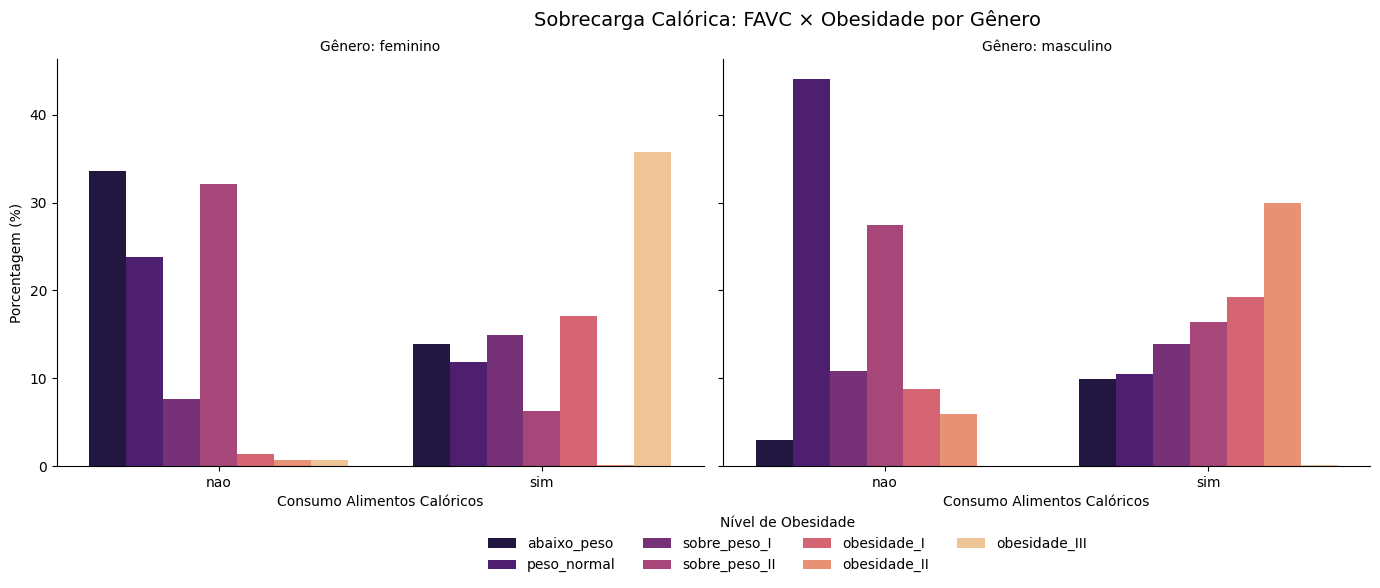

In [123]:
# Plot 2: "Sobrecarga Calórica Comportamental" por Nível de Obesidade e Gênero
sexo_order = ['feminino', 'masculino']
obesity_order = [
    'abaixo_peso', 'peso_normal', 'sobre_peso_I', 'sobre_peso_II',
    'obesidade_I', 'obesidade_II', 'obesidade_III'
]

percentage_data = (
    df_obes.groupby(['sexo', 'Consumo frequente de alimentos calóricos'])
    ['Nível de obesidade (Target)']
    .value_counts(normalize=True).mul(100)
    .rename('percentage').reset_index()
)
g = sns.catplot(
    data=percentage_data,
    x='Consumo frequente de alimentos calóricos',
    y='percentage',
    hue='Nível de obesidade (Target)',
    col='sexo',
    kind='bar',
    palette='magma',
    height=5, aspect=1.4,
    col_order=sexo_order,
    hue_order=obesity_order,
    order=['nao', 'sim'],
)
g.set_axis_labels("Consumo Alimentos Calóricos", "Porcentagem (%)")
g.set_titles("Gênero: {col_name}")
g.fig.suptitle('Sobrecarga Calórica: FAVC × Obesidade por Gênero', y=1.03, fontsize=14)
sns.move_legend(g, loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=4, title='Nível de Obesidade')
plt.show()

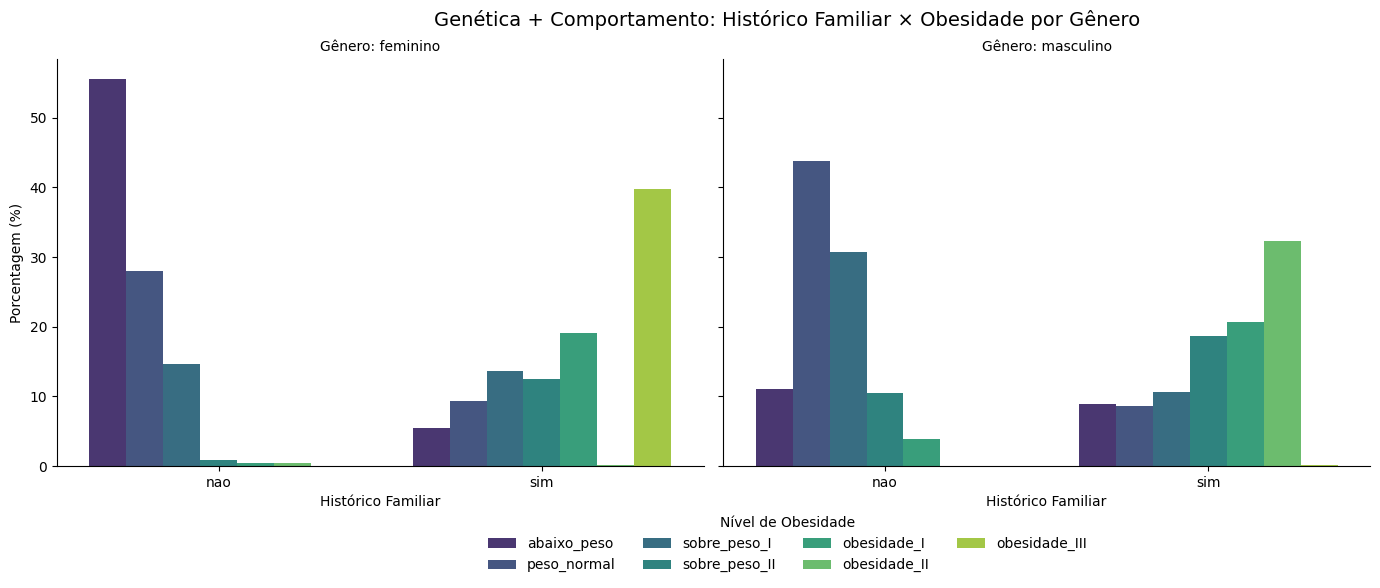

In [124]:
# Plot 3: "Genética + Comportamento" por Nível de Obesidade e Gênero
sexo_order = ['feminino', 'masculino']
obesity_order = [
    'abaixo_peso', 'peso_normal', 'sobre_peso_I', 'sobre_peso_II',
    'obesidade_I', 'obesidade_II', 'obesidade_III'
]

percentage_data = (
    df_obes.groupby(['sexo', 'Histórico familiar de excesso de peso'])
    ['Nível de obesidade (Target)']
    .value_counts(normalize=True).mul(100)
    .rename('percentage').reset_index()
)
g = sns.catplot(
    data=percentage_data,
    x='Histórico familiar de excesso de peso',
    y='percentage',
    hue='Nível de obesidade (Target)',
    col='sexo',
    kind='bar',
    palette='viridis',
    height=5, aspect=1.4,
    col_order=sexo_order,
    hue_order=obesity_order,
    order=['nao', 'sim'],
)
g.set_axis_labels("Histórico Familiar", "Porcentagem (%)")
g.set_titles("Gênero: {col_name}")
g.fig.suptitle('Genética + Comportamento: Histórico Familiar × Obesidade por Gênero', y=1.03, fontsize=14)
sns.move_legend(g, loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=4, title='Nível de Obesidade')
plt.show()

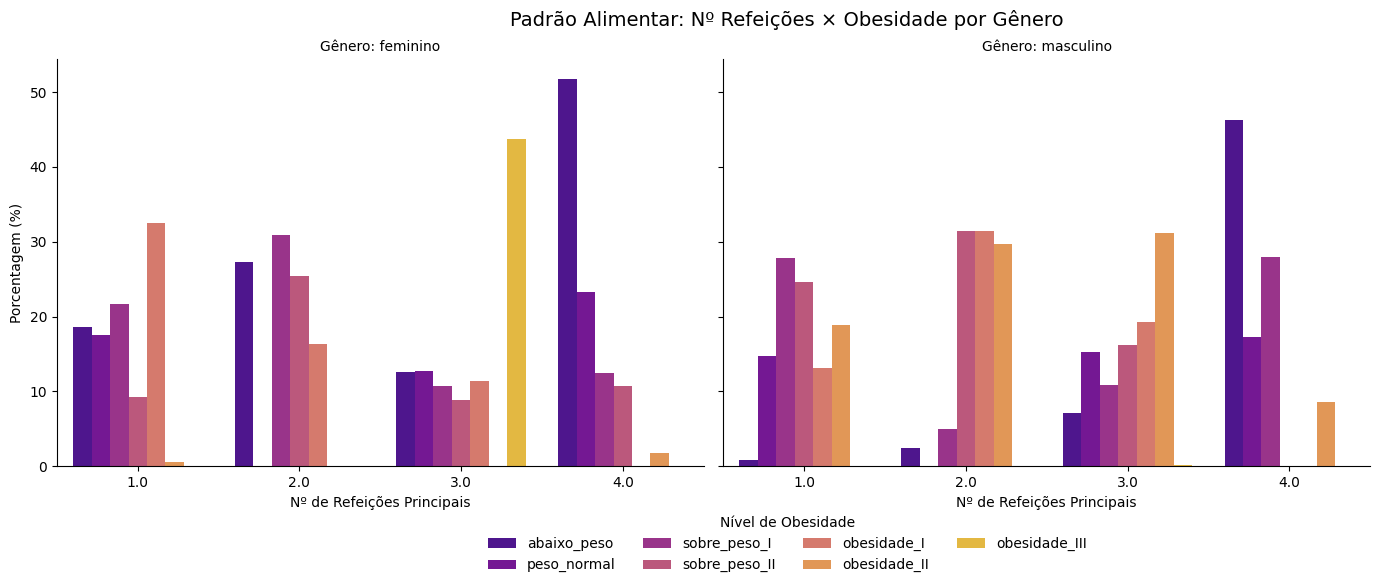

In [125]:
# Plot 4: "Padrão Alimentar Paradoxal" por Nível de Obesidade e Gênero
sexo_order = ['feminino', 'masculino']
obesity_order = [
    'abaixo_peso', 'peso_normal', 'sobre_peso_I', 'sobre_peso_II',
    'obesidade_I', 'obesidade_II', 'obesidade_III'
]

percentage_data = (
    df_obes.groupby(['sexo', 'Número de refeições principais'])
    ['Nível de obesidade (Target)']
    .value_counts(normalize=True).mul(100)
    .rename('percentage').reset_index()
)
g = sns.catplot(
    data=percentage_data,
    x='Número de refeições principais',
    y='percentage',
    hue='Nível de obesidade (Target)',
    col='sexo',
    kind='bar',
    palette='plasma',
    height=5, aspect=1.4,
    col_order=sexo_order,
    hue_order=obesity_order,
    order=sorted(df_obes['Número de refeições principais'].unique()),
)
g.set_axis_labels("Nº de Refeições Principais", "Porcentagem (%)")
g.set_titles("Gênero: {col_name}")
g.fig.suptitle('Padrão Alimentar: Nº Refeições × Obesidade por Gênero', y=1.03, fontsize=14)
sns.move_legend(g, loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=4, title='Nível de Obesidade')
plt.show()

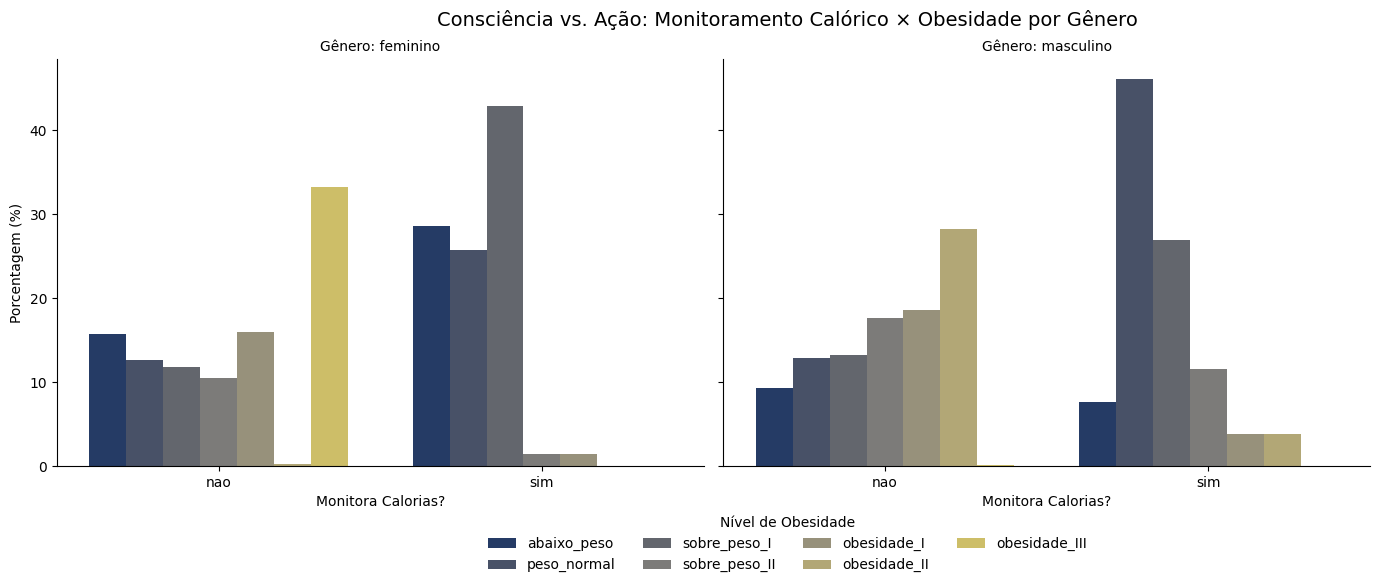

In [126]:
# Plot 5: "Consciência vs. Ação" por Nível de Obesidade e Gênero
sexo_order = ['feminino', 'masculino']
obesity_order = [
    'abaixo_peso', 'peso_normal', 'sobre_peso_I', 'sobre_peso_II',
    'obesidade_I', 'obesidade_II', 'obesidade_III'
]

percentage_data = (
    df_obes.groupby(['sexo', 'Monitoramento de ingestão calórica'])
    ['Nível de obesidade (Target)']
    .value_counts(normalize=True).mul(100)
    .rename('percentage').reset_index()
)
g = sns.catplot(
    data=percentage_data,
    x='Monitoramento de ingestão calórica',
    y='percentage',
    hue='Nível de obesidade (Target)',
    col='sexo',
    kind='bar',
    palette='cividis',
    height=5, aspect=1.4,
    col_order=sexo_order,
    hue_order=obesity_order,
    order=['nao', 'sim'],
)
g.set_axis_labels("Monitora Calorias?", "Porcentagem (%)")
g.set_titles("Gênero: {col_name}")
g.fig.suptitle('Consciência vs. Ação: Monitoramento Calórico × Obesidade por Gênero', y=1.03, fontsize=14)
sns.move_legend(g, loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=4, title='Nível de Obesidade')
plt.show()

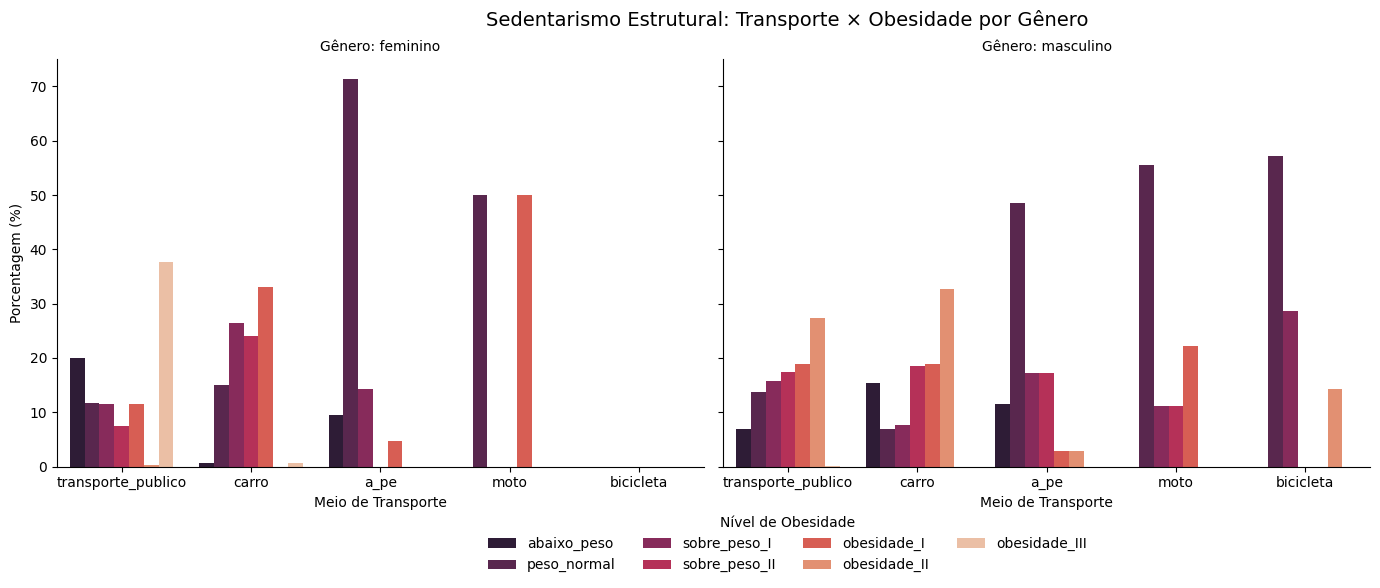

In [127]:
# Plot 6: "Sedentarismo Estrutural" por Nível de Obesidade e Gênero
sexo_order = ['feminino', 'masculino']
obesity_order = [
    'abaixo_peso', 'peso_normal', 'sobre_peso_I', 'sobre_peso_II',
    'obesidade_I', 'obesidade_II', 'obesidade_III'
]

percentage_data = (
    df_obes.groupby(['sexo', 'Meio de transporte habitual'])
    ['Nível de obesidade (Target)']
    .value_counts(normalize=True).mul(100)
    .rename('percentage').reset_index()
)
g = sns.catplot(
    data=percentage_data,
    x='Meio de transporte habitual',
    y='percentage',
    hue='Nível de obesidade (Target)',
    col='sexo',
    kind='bar',
    palette='rocket',
    height=5, aspect=1.4,
    col_order=sexo_order,
    hue_order=obesity_order,
    order=['transporte_publico', 'carro', 'a_pe', 'moto', 'bicicleta'],
)
g.set_axis_labels("Meio de Transporte", "Porcentagem (%)")
g.set_titles("Gênero: {col_name}")
g.fig.suptitle('Sedentarismo Estrutural: Transporte × Obesidade por Gênero', y=1.03, fontsize=14)
sns.move_legend(g, loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=4, title='Nível de Obesidade')
plt.show()

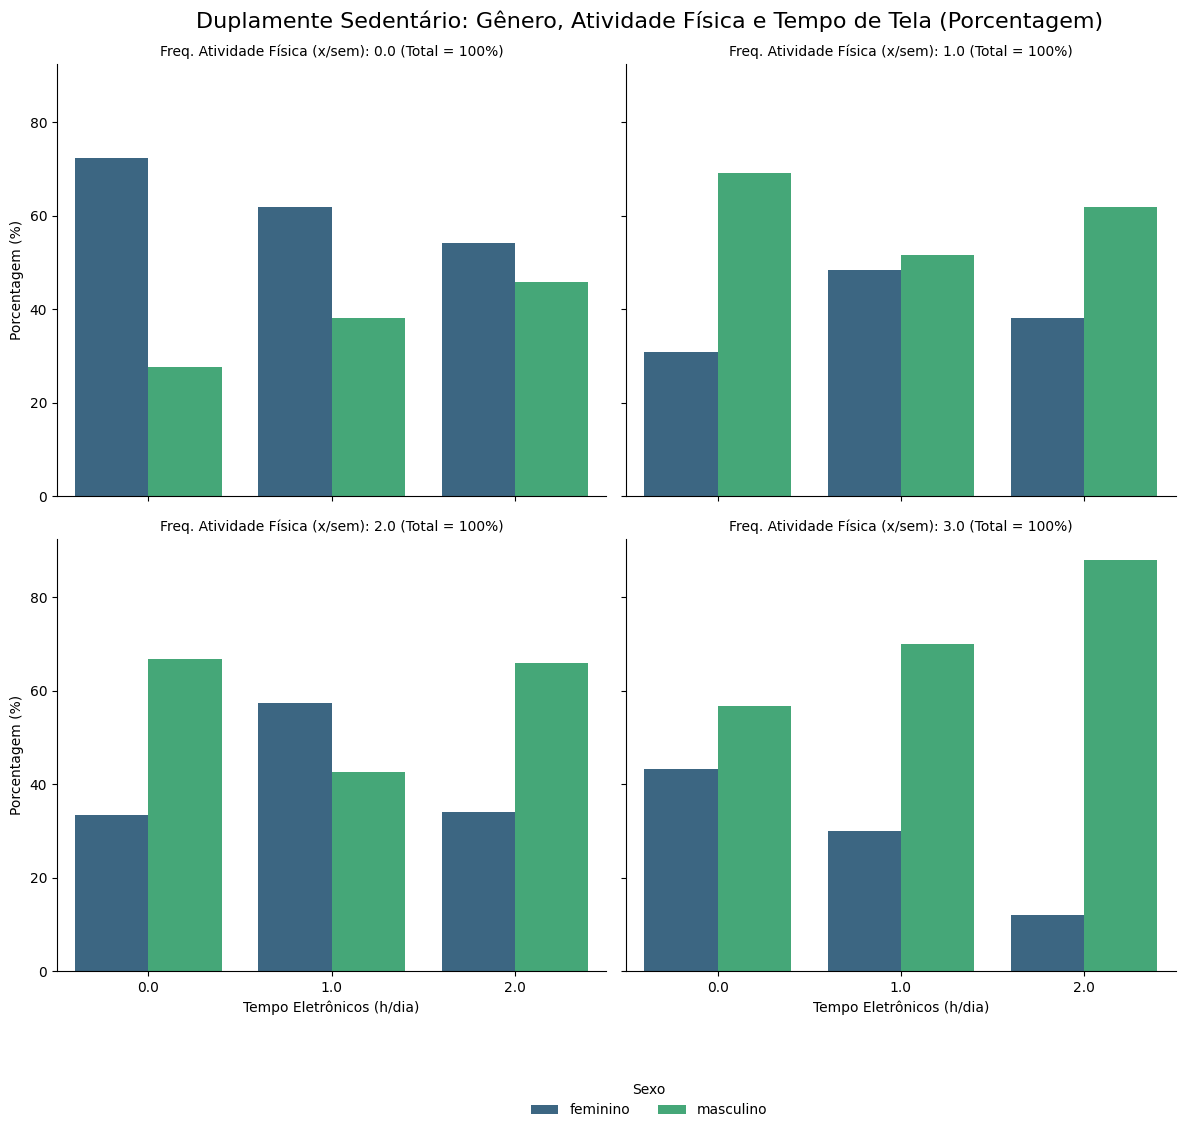

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define consistent order for gender for consistent coloring
sexo_order = ['feminino', 'masculino']

# --- Plot 1: "Duplamente Sedentário" ---
# Columns: 'frequencia semanal atividade fisica (x/semana)' and 'Tempo diário de uso de eletrônicos (h/dia)'
group_cols_for_percentages = ['frequencia semanal atividade fisica (x/semana)', 'Tempo diário de uso de eletrônicos (h/dia)']
percentage_data = df_obes.groupby(group_cols_for_percentages)['sexo'].value_counts(normalize=True).mul(100).rename('percentage').reset_index()

g = sns.catplot(
    data=percentage_data,
    x='Tempo diário de uso de eletrônicos (h/dia)',
    y='percentage',
    hue='sexo',
    col='frequencia semanal atividade fisica (x/semana)',
    kind='bar',
    palette='viridis',
    height=5, aspect=1.2,
    col_wrap=2,
    order=sorted(df_obes['Tempo diário de uso de eletrônicos (h/dia)'].unique()),
    col_order=sorted(df_obes['frequencia semanal atividade fisica (x/semana)'].unique()),
    hue_order=sexo_order,

)
g.set_axis_labels("Tempo Eletrônicos (h/dia)", "Porcentagem (%)")
g.set_titles("Freq. Atividade Física (x/sem): {col_name} (Total = 100%)")
g.fig.suptitle('Duplamente Sedentário: Gênero, Atividade Física e Tempo de Tela (Porcentagem)', y=1.02, fontsize=16)
sns.move_legend(
    g,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(obesity_order),
    title='Sexo'
)
plt.show()

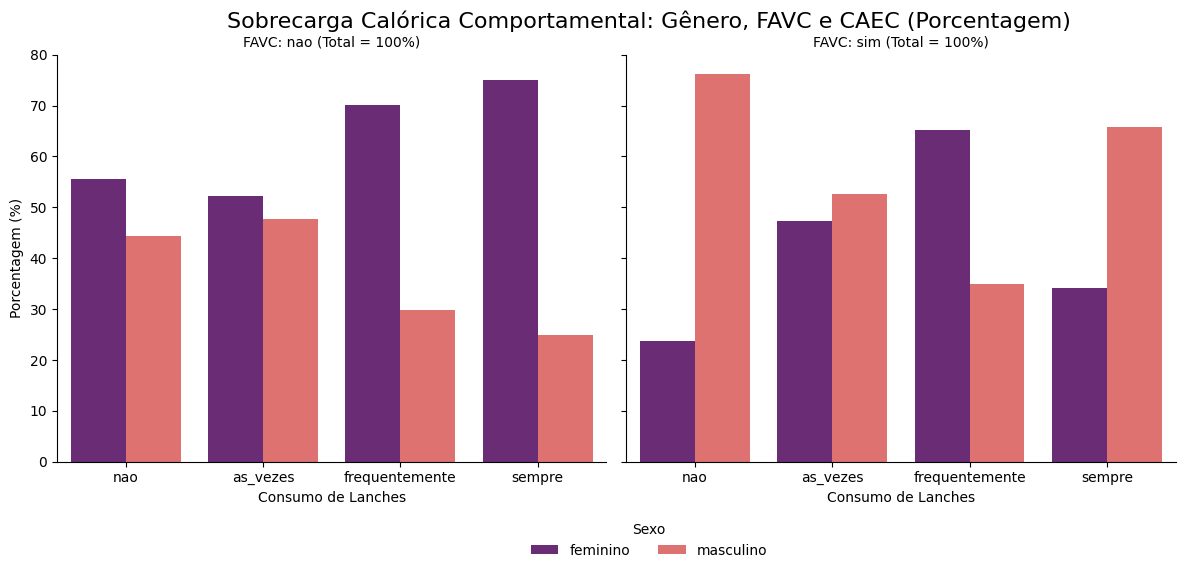

In [78]:
# --- Plot 2: "Sobrecarga Calórica Comportamental" ---
# Columns: 'Consumo frequente de alimentos calóricos' and 'Consumo de lanches entre refeições'
sexo_order = ['feminino', 'masculino']

group_cols_for_percentages = ['Consumo frequente de alimentos calóricos', 'Consumo de lanches entre refeições']
percentage_data = df_obes.groupby(group_cols_for_percentages)['sexo'].value_counts(normalize=True).mul(100).rename('percentage').reset_index()

g = sns.catplot(
    data=percentage_data,
    x='Consumo de lanches entre refeições',
    y='percentage',
    hue='sexo',
    col='Consumo frequente de alimentos calóricos',
    kind='bar',
    palette='magma',
    height=5, aspect=1.2,
    col_wrap=2,
    hue_order=sexo_order,
    order=['nao', 'as_vezes', 'frequentemente', 'sempre'], # Order for Consumo de lanches entre refeições
    col_order=['nao', 'sim'],

)
g.set_axis_labels("Consumo de Lanches", "Porcentagem (%)")
g.set_titles("FAVC: {col_name} (Total = 100%)")
g.fig.suptitle('Sobrecarga Calórica Comportamental: Gênero, FAVC e CAEC (Porcentagem)', y=1.02, fontsize=16)
sns.move_legend(
    g,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(obesity_order),
    title='Sexo'
)
plt.show()

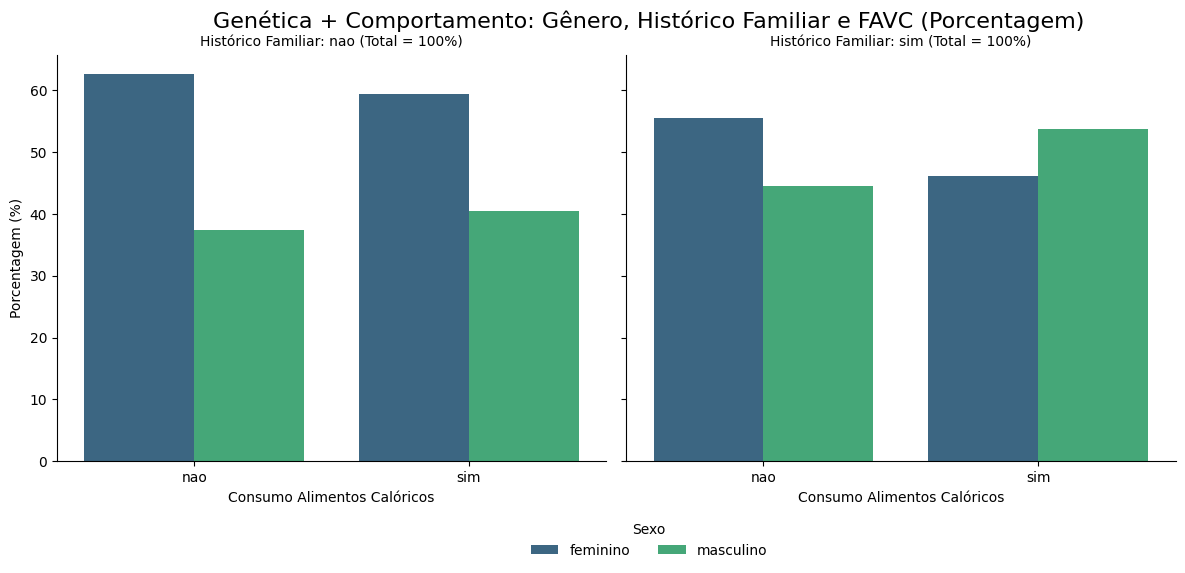

In [79]:
# --- Plot 3: "Genética + Comportamento" ---
# Columns: 'Histórico familiar de excesso de peso' and 'Consumo frequente de alimentos calóricos'
sexo_order = ['feminino', 'masculino']

group_cols_for_percentages = ['Histórico familiar de excesso de peso', 'Consumo frequente de alimentos calóricos']
percentage_data = df_obes.groupby(group_cols_for_percentages)['sexo'].value_counts(normalize=True).mul(100).rename('percentage').reset_index()

g = sns.catplot(
    data=percentage_data,
    x='Consumo frequente de alimentos calóricos',
    y='percentage',
    hue='sexo',
    col='Histórico familiar de excesso de peso',
    kind='bar',
    palette='viridis',
    height=5, aspect=1.2,
    col_wrap=2,
    hue_order=sexo_order,
    order=['nao', 'sim'], # Order for Consumo frequente de alimentos calóricos
    col_order=['nao', 'sim'],

)
g.set_axis_labels("Consumo Alimentos Calóricos", "Porcentagem (%)")
g.set_titles("Histórico Familiar: {col_name} (Total = 100%)")
g.fig.suptitle('Genética + Comportamento: Gênero, Histórico Familiar e FAVC (Porcentagem)', y=1.02, fontsize=16)
sns.move_legend(
    g,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(obesity_order),
    title='Sexo'
)
plt.show()

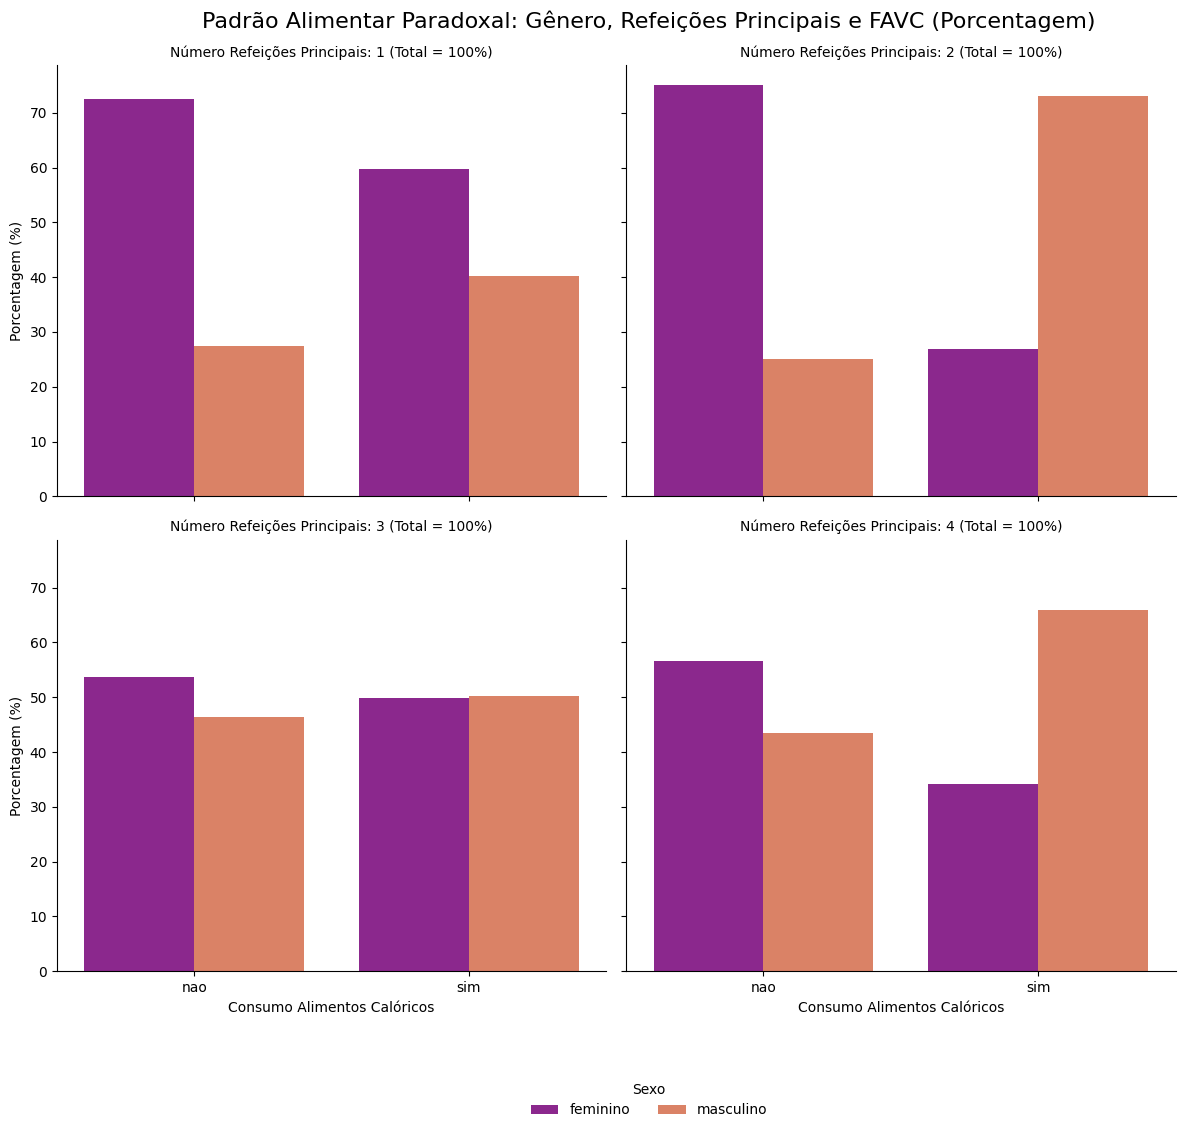

In [80]:
# --- Plot 4: "Padrão Alimentar Paradoxal" ---
# Columns: 'Número de refeições principais' and 'Consumo frequente de alimentos calóricos'
sexo_order = ['feminino', 'masculino']

group_cols_for_percentages = ['Número de refeições principais', 'Consumo frequente de alimentos calóricos']
percentage_data = df_obes.groupby(group_cols_for_percentages)['sexo'].value_counts(normalize=True).mul(100).rename('percentage').reset_index()

g = sns.catplot(
    data=percentage_data,
    x='Consumo frequente de alimentos calóricos',
    y='percentage',
    hue='sexo',
    col='Número de refeições principais',
    kind='bar',
    palette='plasma',
    height=5, aspect=1.2,
    col_wrap=2,
    hue_order=sexo_order,
    order=['nao', 'sim'], # Order for Consumo frequente de alimentos calóricos
    col_order=[1, 2, 3, 4],

)
g.set_axis_labels("Consumo Alimentos Calóricos", "Porcentagem (%)")
g.set_titles("Número Refeições Principais: {col_name} (Total = 100%)")
g.fig.suptitle('Padrão Alimentar Paradoxal: Gênero, Refeições Principais e FAVC (Porcentagem)', y=1.02, fontsize=16)
sns.move_legend(
    g,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(obesity_order),
    title='Sexo'
)
plt.show()

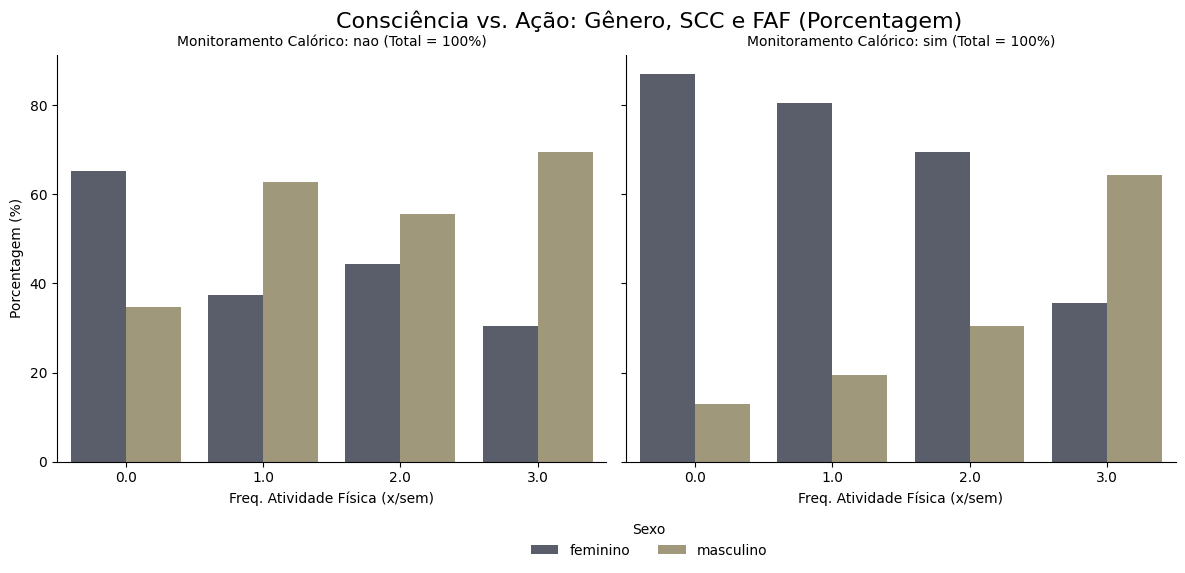

In [95]:
# --- Plot 5: "Consciência vs. Ação" ---
# Columns: 'Monitoramento de ingestão calórica' and 'frequencia semanal atividade fisica (x/semana)'
sexo_order = ['feminino', 'masculino']

group_cols_for_percentages = ['Monitoramento de ingestão calórica', 'frequencia semanal atividade fisica (x/semana)']
percentage_data = df_obes.groupby(group_cols_for_percentages)['sexo'].value_counts(normalize=True).mul(100).rename('percentage').reset_index()

g = sns.catplot(
    data=percentage_data,
    x='frequencia semanal atividade fisica (x/semana)',
    y='percentage',
    hue='sexo',
    col='Monitoramento de ingestão calórica',
    kind='bar',
    palette='cividis',
    height=5, aspect=1.2,
    col_wrap=2,
    hue_order=sexo_order,
    order=sorted(df_obes['frequencia semanal atividade fisica (x/semana)'].unique()),
    col_order=['nao', 'sim'],

)
g.set_axis_labels("Freq. Atividade Física (x/sem)", "Porcentagem (%)")
g.set_titles("Monitoramento Calórico: {col_name} (Total = 100%)")
g.fig.suptitle('Consciência vs. Ação: Gênero, SCC e FAF (Porcentagem)', y=1.02, fontsize=16)
sns.move_legend(
    g,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(obesity_order),
    title='Sexo'
)
plt.show()

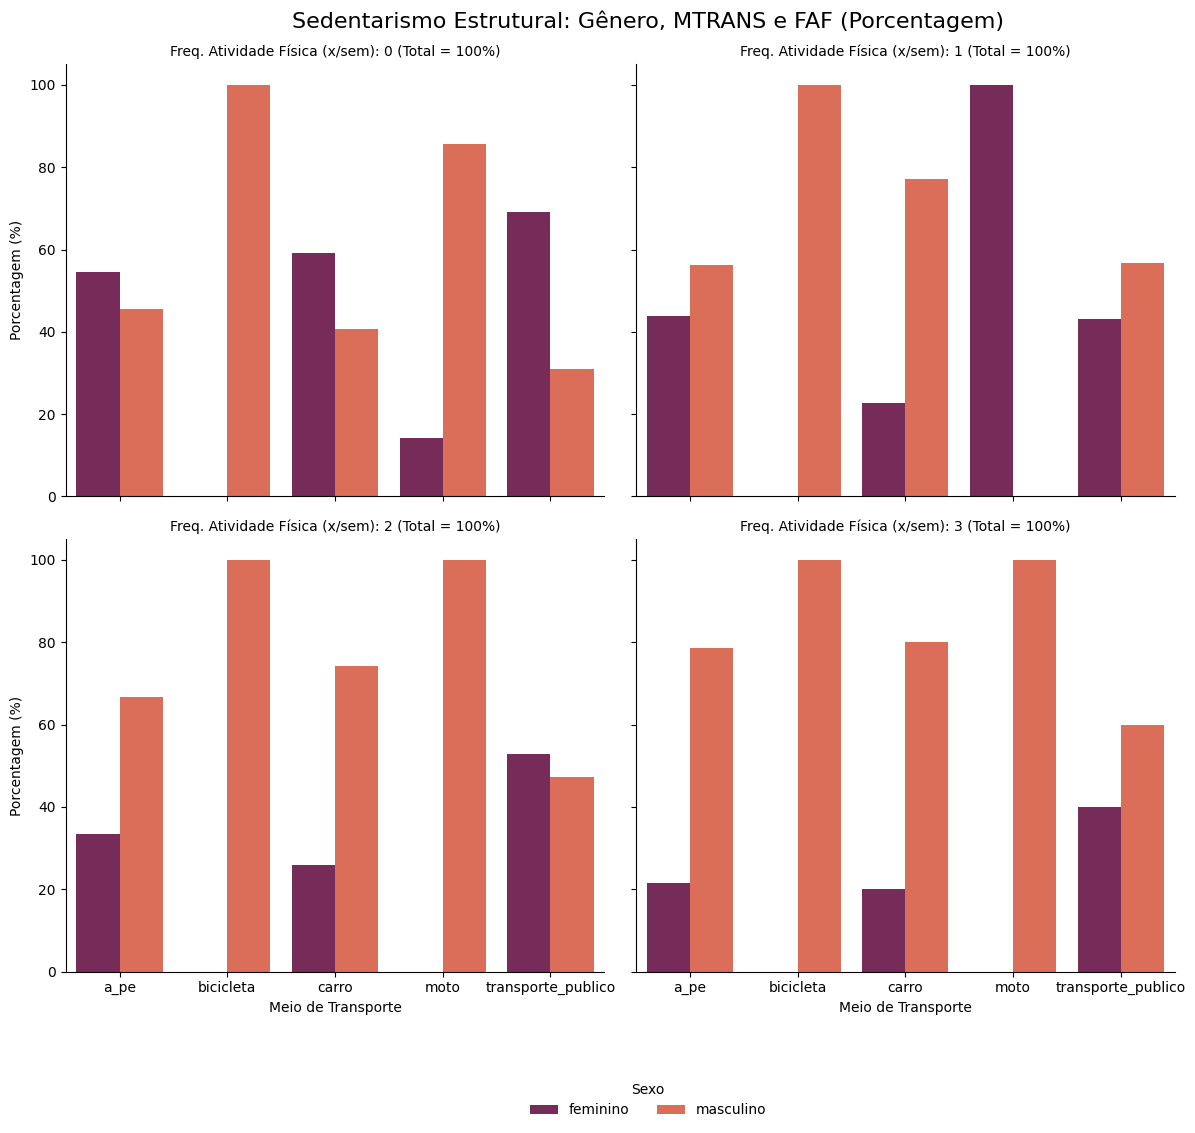

In [82]:
# --- Plot 6: "Sedentarismo Estrutural" ---
# Columns: 'Meio de transporte habitual' and 'frequencia semanal atividade fisica (x/semana)'
sexo_order = ['feminino', 'masculino']

group_cols_for_percentages = ['frequencia semanal atividade fisica (x/semana)', 'Meio de transporte habitual']
percentage_data = df_obes.groupby(group_cols_for_percentages)['sexo'].value_counts(normalize=True).mul(100).rename('percentage').reset_index()

g = sns.catplot(
    data=percentage_data,
    x='Meio de transporte habitual',
    y='percentage',
    hue='sexo',
    col='frequencia semanal atividade fisica (x/semana)',
    kind='bar',
    palette='rocket',
    height=5, aspect=1.2,
    col_wrap=2,
    hue_order=sexo_order,
    col_order=[0, 1, 2, 3],

)
g.set_axis_labels("Meio de Transporte", "Porcentagem (%)")
g.set_titles("Freq. Atividade Física (x/sem): {col_name} (Total = 100%)")
g.fig.suptitle('Sedentarismo Estrutural: Gênero, MTRANS e FAF (Porcentagem)', y=1.02, fontsize=16)
sns.move_legend(
    g,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(obesity_order),
    title='Sexo'
)
plt.show()

In [50]:
from google.colab import files
df_obes.to_csv('dados_obesidade_limpos.csv', index=False)
files.download('dados_obesidade_limpos.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>